# LTV Candidate Review Separability

This notebook inspects the reviewed LTV-candidate queue in `output/ltv/ltv/ltv_candidates.db`.
It is meant to answer four practical questions:

- What was actually reviewed, and which candidates are in each human label bucket?
- Which measured features differ between `event_class='ltv'` and `event_class='instrumental'`?
- Do simple statistical tests or baseline classifiers suggest separability?
- What do the `other`, `unknown_interesting`, and `dipper` reviewed subsets look like?

The notebook is read-only with respect to the review DB.


## Setup

The path resolution below works whether the notebook is opened from the repo root or from `malca/notebooks`.


In [1]:
from __future__ import annotations

import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/malca-mplconfig")

import json
import math
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

root_candidates = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (
        p
        for p in root_candidates
        if (p / "malca").is_dir()
        and (p / "output" / "ltv" / "ltv" / "ltv_candidates.db").exists()
    ),
    Path.cwd(),
)
DB_PATH = REPO_ROOT / "output" / "ltv" / "ltv" / "ltv_candidates.db"
FRESH_DB_PATH = REPO_ROOT / "output" / "ltv" / "ltv" / "ltv_candidates_fresh.db"
ROOT_LTV_DB_PATH = REPO_ROOT / "ltv_candidates.db"

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"DB_PATH   = {DB_PATH}")
print(f"exists    = {DB_PATH.exists()}")


REPO_ROOT = /home/calder/code/malca
DB_PATH   = /home/calder/code/malca/output/ltv/ltv/ltv_candidates.db
exists    = True


## Load Reviewed Candidates

This joins `candidates` to `reviews` and keeps both reviewed rows and the full imported queue for completion checks.


In [2]:
if not DB_PATH.exists():
    raise FileNotFoundError(DB_PATH)

with sqlite3.connect(DB_PATH) as conn:
    reviewed = pd.read_sql_query(
        """
        SELECT
            c.*,
            r.status AS review_status,
            r.interest_score,
            r.event_class,
            r.review_pass,
            r.notes,
            r.reviewer,
            r.updated_at
        FROM candidates c
        JOIN reviews r USING(candidate_id)
        WHERE COALESCE(r.status, '') NOT IN ('', 'unreviewed')
        """,
        conn,
    )
    all_candidates = pd.read_sql_query("SELECT * FROM candidates", conn)
    reviews = pd.read_sql_query("SELECT * FROM reviews", conn)
    app_state = pd.read_sql_query("SELECT * FROM app_state", conn)

reviewed["updated_at"] = pd.to_datetime(reviewed["updated_at"], errors="coerce", utc=True)
for col in ["interest_score", "review_pass"]:
    reviewed[col] = pd.to_numeric(reviewed[col], errors="coerce")

print(f"All candidates in DB: {len(all_candidates):,}")
print(f"Reviewed rows:        {len(reviewed):,}")
print(f"Review rows:          {len(reviews):,}")
print(f"Unreviewed/missing:   {len(all_candidates) - len(reviews):,}")
display(reviewed["event_class"].value_counts(dropna=False).rename_axis("event_class").reset_index(name="n"))
display(app_state.loc[app_state["key"].isin(["review_last_candidate", "last_input_file"])])


All candidates in DB: 868
Reviewed rows:        588
Review rows:          588
Unreviewed/missing:   280


,event_class,n
0,instrumental,459
1,other,67
2,ltv,59
3,unknown_interesting,2
4,dipper,1


,key,value,updated_at
0,review_last_candidate,ltv_584116351091,2026-03-19T23:54:57.774632+00:00


## Candidate Tables

These are compact review tables for each label. The variables stay in memory, so change `max_rows` or `sort_by` to inspect more rows.


In [3]:
KEY_DISPLAY_COLS = [
    "candidate_id", "asas_sn_id", "event_class", "review_status", "interest_score", "review_pass",
    "updated_at", "notes", "lc_path",
    "ltv_slope", "ltv_dispersion", "ltv_max_diff", "ltv_median", "ltv_ls_power", "ltv_ls_fap",
    "ltv_neowise_w1_slope", "ltv_neowise_w1_w2_slope", "ltv_passed_filters", "ltv_dust_candidate",
    "ltv_vsx_match", "ltv_milliquas_match", "ltv_gaia_alert_match",
    "baseline_mag", "n_points", "n_cameras", "pm_total", "ruwe",
    "periodicity_score", "dipper_score", "jumper_score", "catalog_match", "catalog_source",
    "asassn_var_type", "gaia_var_class", "simbad_otype", "ztf_var_type", "microlens_match",
]
KEY_DISPLAY_COLS = [c for c in KEY_DISPLAY_COLS if c in reviewed.columns]

CLASS_ORDER = ["ltv", "instrumental", "other", "unknown_interesting", "dipper"]

def candidate_table(label: str | None = None, max_rows: int = 80, sort_by: str = "interest_score") -> pd.DataFrame:
    data = reviewed.copy()
    if label is not None:
        data = data.loc[data["event_class"].eq(label)].copy()
    sort_cols = [c for c in [sort_by, "updated_at", "candidate_id"] if c in data.columns]
    ascending = [False if c in {"interest_score", "updated_at"} else True for c in sort_cols]
    if sort_cols:
        data = data.sort_values(sort_cols, ascending=ascending)
    return data[KEY_DISPLAY_COLS].head(max_rows)

for label in CLASS_ORDER:
    display(Markdown(f"### {label}: {int((reviewed['event_class'] == label).sum())} reviewed"))
    display(candidate_table(label, max_rows=80))


### ltv: 59 reviewed

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
259,ltv_111669856568,111669856568,ltv,reviewed,4,1,2026-03-19 05:55:58.496730+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.758585,2.797280,40.317527,14.709300,0.076797,8.777440e-04,None,None,1,0,0,0,0,15.105467,597.0,5.0,5.745444,NaN,None,None,None,None,None,None,None,None,None,None
271,ltv_8590385724,8590385724,ltv,reviewed,4,2,2026-03-19 04:15:49.310381+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.345165,2.676851,85.822543,15.580103,NaN,2.725001e-01,None,None,1,0,0,0,0,15.617152,839.0,4.0,8.321673,NaN,None,None,None,None,None,None,None,None,None,None
92,ltv_532576249378,532576249378,ltv,reviewed,4,2,2026-03-19 04:14:56.261685+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.428835,3.222512,68.863226,13.463613,0.023120,7.748621e-05,None,None,1,0,0,0,0,13.574400,1745.0,6.0,4.407826,NaN,None,None,None,None,None,None,None,None,None,None
342,ltv_566935854235,566935854235,ltv,reviewed,4,2,2026-03-19 04:08:05.189203+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.664676,5.404100,85.021103,11.940946,0.108486,3.776392e-03,None,None,1,0,0,0,0,13.423869,344.0,2.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
115,ltv_455266711850,455266711850,ltv,reviewed,4,2,2026-03-19 01:21:44.702776+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.332944,4.973500,94.554564,12.870600,NaN,5.142559e-01,None,None,1,0,0,0,0,12.872121,556.0,2.0,2.992907,NaN,None,None,None,None,None,None,None,None,None,None
55,ltv_128849057178,128849057178,ltv,reviewed,4,2,2026-03-19 01:06:17.315252+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.312893,1.358643,39.769925,13.441043,NaN,9.163585e-01,None,None,1,0,0,0,0,14.133700,881.0,5.0,7.528610,NaN,None,None,None,None,None,None,None,None,None,None
274,ltv_335007583782,335007583782,ltv,reviewed,4,2,2026-03-19 00:25:17.022359+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.307088,2.268100,50.842340,13.133356,NaN,4.479285e-01,None,None,1,0,0,0,0,13.963634,1777.0,10.0,5.099226,NaN,None,None,None,None,None,None,None,*,None,None
56,ltv_17181261656,17181261656,ltv,reviewed,3,2,2026-03-19 00:33:49.238678+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.327868,5.048904,104.521719,15.812015,0.537773,2.140304e-120,None,None,1,0,0,0,1,15.812015,744.0,5.0,4.397414,NaN,None,None,None,None,None,None,None,Mi*,None,None
172,ltv_627066103329,627066103329,ltv,reviewed,2,2,2026-03-19 04:22:32.062188+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.372589,5.687807,83.802991,14.422857,0.262807,2.865081e-60,None,None,1,0,0,0,1,14.422857,970.0,3.0,8.321673,NaN,None,None,None,None,None,None,None,Mi*,None,None
479,ltv_515397191397,515397191397,ltv,reviewed,2,2,2026-03-19 04:21:24.846157+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.300690,4.662889,79.389612,15.501280,0.371098,7.055976e-75,None,None,1,0,0,0,1,15.501280,783.0,3.0,NaN,NaN,None,None,None,None,None,None,None,Mi*,None,None


### instrumental: 459 reviewed

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
299,ltv_1188924,1188924,instrumental,reviewed,4,2,2026-03-19 04:48:48.770095+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.396163,2.231300,45.353150,13.707000,NaN,7.612142e-01,None,None,1,0,0,0,0,13.706100,165.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
305,ltv_17181131773,17181131773,instrumental,reviewed,4,2,2026-03-19 04:23:34.488360+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.361780,2.030100,50.040913,14.278000,NaN,5.830651e-01,None,None,1,0,0,0,0,14.269200,167.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
187,ltv_1093601,1093601,instrumental,reviewed,4,2,2026-03-19 04:23:28.640008+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.431238,2.106900,60.138700,13.577200,NaN,9.903882e-01,None,None,1,0,0,0,0,13.571550,170.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
508,ltv_1193893,1193893,instrumental,reviewed,4,2,2026-03-19 04:23:22.543428+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.423719,2.168200,59.979613,14.574300,NaN,1.399615e-01,None,None,1,0,0,0,0,14.572500,165.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
136,ltv_1126523,1126523,instrumental,reviewed,4,2,2026-03-19 04:22:54.460445+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.411152,2.051700,60.758657,13.504850,NaN,9.836246e-01,None,None,1,0,0,0,0,13.504850,168.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
568,ltv_1194068,1194068,instrumental,reviewed,4,2,2026-03-19 04:22:46.875627+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.370583,1.988500,63.000112,14.896500,0.124530,4.666718e-02,None,None,1,0,0,0,0,14.892800,167.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
331,ltv_549756087752,549756087752,instrumental,reviewed,4,2,2026-03-19 04:22:41.023098+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.697343,60.296820,7.391517,-2.534893,NaN,9.989158e-01,None,None,1,0,0,0,0,-5.782450,434.0,2.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
557,ltv_1153218,1153218,instrumental,reviewed,4,2,2026-03-19 04:22:24.203885+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.309682,2.132100,78.892643,14.874900,0.148317,6.931762e-03,None,None,1,0,0,0,0,14.869000,167.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
26,ltv_17181126314,17181126314,instrumental,reviewed,4,3,2026-03-19 04:22:19.240199+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.488964,2.368300,46.663469,12.315300,0.245238,1.638560e-07,None,None,1,0,0,0,0,12.315500,169.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
306,ltv_1100161,1100161,instrumental,reviewed,4,2,2026-03-19 04:22:17.257861+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.389632,1.933400,63.090514,13.807400,NaN,9.550856e-01,None,None,1,0,0,0,0,13.804100,171.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


### other: 67 reviewed

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
47,ltv_51539958368,51539958368,other,reviewed,4,2,2026-03-19 01:52:20.349919+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.336802,1.030618,33.690594,12.481700,NaN,6.242929e-01,None,None,1,0,0,0,1,12.501300,119.0,1.0,6.904001,NaN,None,None,None,None,None,None,None,EB*,EA,None
46,ltv_206159246990,206159246990,other,reviewed,4,2,2026-03-19 01:48:51.550472+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.345937,4.915728,81.346665,13.670900,NaN,2.855446e-01,None,None,1,0,0,0,0,13.685200,321.0,3.0,6.519397,NaN,None,None,None,None,None,None,None,None,None,None
13,ltv_85899492461,85899492461,other,reviewed,4,2,2026-03-19 01:22:51.051906+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.485362,3.901812,68.018575,12.287482,NaN,4.948385e-01,None,None,1,0,0,0,0,12.289083,394.0,4.0,8.757862,NaN,None,None,None,None,None,None,None,*,None,None
7,ltv_154619236699,154619236699,other,reviewed,4,2,2026-03-19 01:22:39.063202+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.351300,0.953800,32.247300,12.037300,NaN,6.998849e-01,None,None,1,0,0,0,0,12.047950,118.0,1.0,3.688668,NaN,None,None,None,None,None,None,None,*,None,None
99,ltv_51540578234,51540578234,other,reviewed,4,2,2026-03-19 01:22:28.537600+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.632667,5.483800,89.422282,13.260400,NaN,5.290693e-01,None,None,1,0,0,0,0,13.264300,136.0,1.0,12.759916,NaN,None,None,None,None,None,None,None,None,None,None
40,ltv_627066258907,627066258907,other,reviewed,4,2,2026-03-19 01:22:17.740548+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,2.140613,27.162600,184.120212,12.109426,NaN,3.424761e-01,None,None,1,0,0,0,0,12.111826,557.0,2.0,2.822461,0.673915,None,None,None,None,None,None,None,None,None,None
468,ltv_438087413518,438087413518,other,reviewed,4,2,2026-03-19 00:16:15.826641+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.341937,2.366800,108.481871,16.318950,0.118131,3.362288e-02,None,None,1,0,0,0,0,16.330300,175.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
41,ltv_635655992254,635655992254,other,reviewed,4,2,2026-03-19 00:09:05.557224+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.616358,5.434500,85.349196,13.728612,NaN,8.958808e-01,None,None,1,0,0,0,0,14.023082,275.0,3.0,0.451128,NaN,None,None,None,None,None,None,None,None,None,None
15,ltv_644245411813,644245411813,other,reviewed,4,2,2026-03-19 00:06:53.275489+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.330155,5.071680,63.265373,12.089941,0.025879,8.571713e-11,None,None,1,0,1,0,0,12.083059,1552.0,5.0,7.528610,NaN,None,None,None,None,None,None,None,None,None,None
434,ltv_644246006094,644246006094,other,reviewed,4,2,2026-03-19 00:06:09.590974+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.462107,3.157300,59.671243,13.898700,NaN,9.998415e-01,None,None,1,0,0,0,0,13.974000,305.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


### unknown_interesting: 2 reviewed

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
260,ltv_618475941815,618475941815,unknown_interesting,reviewed,4,2,2026-03-19 04:48:37.761014+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.366041,4.963752,81.256214,16.127190,0.437744,3.375524e-121,None,None,1,0,0,0,1,16.12719,1003.0,6.0,6.856572,NaN,None,None,None,None,None,None,None,Mi*,None,None
80,ltv_489626718831,489626718831,unknown_interesting,reviewed,1,2,2026-03-19 01:33:53.544517+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.350557,4.700219,48.693471,10.781674,NaN,1.078671e-01,None,None,1,0,0,0,0,11.22375,596.0,5.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


### dipper: 1 reviewed

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
8,ltv_17180383194,17180383194,dipper,reviewed,1,2,2026-03-19 01:45:58.951049+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.311442,4.10887,66.89557,12.202554,NaN,0.674776,None,None,1,0,0,0,0,12.212355,296.0,3.0,5.629421,NaN,None,None,None,None,None,None,None,None,None,None


## Group-Level Review Summary

Use this to catch review-label distribution issues before interpreting statistical differences. In this set, note that `interest_score` is a human-review field, so it is not used as a predictive feature later.


In [4]:
review_summary = (
    reviewed.groupby("event_class", dropna=False)
    .agg(
        n=("candidate_id", "size"),
        mean_interest=("interest_score", "mean"),
        median_interest=("interest_score", "median"),
        high_interest=("interest_score", lambda s: int((s >= 3).sum())),
        min_updated=("updated_at", "min"),
        max_updated=("updated_at", "max"),
    )
    .sort_values("n", ascending=False)
)
review_summary["high_interest_frac"] = review_summary["high_interest"] / review_summary["n"]
display(review_summary)

reviewed_by_pass = pd.crosstab(reviewed["event_class"], reviewed["review_pass"], margins=True)
display(reviewed_by_pass)


,n,mean_interest,median_interest,high_interest,min_updated,max_updated,high_interest_frac
event_class,,,,,,,
instrumental,459,3.917211,4.0,446,2026-03-19 00:16:30.936548+00:00,2026-03-19 04:48:48.770095+00:00,0.971678
other,67,2.477612,2.0,32,2026-03-19 00:01:58.863776+00:00,2026-03-19 04:17:50.576734+00:00,0.477612
ltv,59,1.542373,1.0,8,2026-03-19 00:06:41.114061+00:00,2026-03-19 05:55:58.496730+00:00,0.135593
unknown_interesting,2,2.500000,2.5,1,2026-03-19 01:33:53.544517+00:00,2026-03-19 04:48:37.761014+00:00,0.500000
dipper,1,1.000000,1.0,0,2026-03-19 01:45:58.951049+00:00,2026-03-19 01:45:58.951049+00:00,0.000000


review_pass,1,2,3,All
event_class,,,,
dipper,0,1,0,1
instrumental,0,453,6,459
ltv,1,56,2,59
other,0,66,1,67
unknown_interesting,0,2,0,2
All,1,578,9,588


## Feature Preparation

This cell builds analysis feature sets from numeric columns and low-cardinality categorical/flag columns. It excludes human-review fields and IDs.


In [5]:
# A few useful derived columns.
analysis = reviewed.copy()
for col in ["ltv_slope", "ltv_slope_quad", "ltv_neowise_w1_slope", "ltv_neowise_w1_w2_slope", "pmra", "pmdec"]:
    if col in analysis.columns:
        analysis[f"abs_{col}"] = pd.to_numeric(analysis[col], errors="coerce").abs()

if {"pmra", "pmdec"}.issubset(analysis.columns) and "pm_total" not in analysis.columns:
    analysis["pm_total"] = np.sqrt(pd.to_numeric(analysis["pmra"], errors="coerce") ** 2 + pd.to_numeric(analysis["pmdec"], errors="coerce") ** 2)

EXCLUDE_FEATURES = {
    "interest_score", "review_pass", "updated_at", "candidate_id", "asas_sn_id", "source_path",
    "lc_path", "payload_json", "imported_at", "review_status", "event_class", "notes", "reviewer",
}

numeric_cols = []
for col in analysis.columns:
    if col in EXCLUDE_FEATURES:
        continue
    s = pd.to_numeric(analysis[col], errors="coerce")
    if s.notna().sum() >= 25 and s.nunique(dropna=True) > 1:
        numeric_cols.append(col)
        analysis[col] = s

low_card_cols = []
for col in analysis.columns:
    if col in EXCLUDE_FEATURES or col in numeric_cols:
        continue
    nunique = analysis[col].nunique(dropna=True)
    nonmissing = analysis[col].notna().sum()
    if 2 <= nunique <= 20 and nonmissing >= 25:
        low_card_cols.append(col)

print(f"Numeric analysis columns: {len(numeric_cols)}")
print(f"Low-cardinality categorical columns: {len(low_card_cols)}")
print("Numeric examples:", numeric_cols[:30])
print("Categorical examples:", low_card_cols[:30])


Numeric analysis columns: 162
Low-cardinality categorical columns: 2
Numeric examples: ['pmra', 'pmdec', 'A_v_3d', 'simbad_sep_arcsec', 'n_points', 'n_cameras', 'baseline_mag', 'cadence_median_days', 'stats_file_points_total', 'stats_file_points_kept_after_filter', 'stats_jd_start', 'stats_jd_end', 'stats_time_span_days', 'stats_n_unique_nights', 'stats_duty_cycle_fraction', 'stats_cadence_mean_dt_days', 'stats_cadence_median_dt_days', 'stats_cadence_p05_dt_days', 'stats_cadence_p95_dt_days', 'stats_photometry_mean_mag', 'stats_photometry_median_mag', 'stats_photometry_weighted_mean_mag', 'stats_photometry_weighted_mean_sem', 'stats_photometry_weighted_std_mag', 'stats_photometry_std_mag', 'stats_photometry_robust_sigma_mag', 'stats_photometry_IQR_mag', 'stats_photometry_p05_mag', 'stats_photometry_p16_mag', 'stats_photometry_p84_mag']
Categorical examples: ['population', 'simbad_otype']


## Hand-Picked LTV Metrics By Class

These are the most interpretable LTV and quality-control fields. The broader statistical scan follows in the next section.


In [6]:
INTERPRETABLE_FEATURES = [
    "ltv_slope", "abs_ltv_slope", "ltv_slope_quad", "abs_ltv_slope_quad", "ltv_dispersion", "ltv_max_diff",
    "ltv_median", "ltv_median_err", "ltv_ls_power", "ltv_ls_fap", "ltv_coeff1", "ltv_coeff2",
    "ltv_vg_overlap_days", "ltv_vg_overlap_fraction", "ltv_neowise_w1_slope", "abs_ltv_neowise_w1_slope",
    "ltv_neowise_w1_w2_slope", "abs_ltv_neowise_w1_w2_slope", "ltv_neowise_n_epochs",
    "baseline_mag", "n_points", "n_cameras", "pm_total", "ruwe", "A_v_3d", "ebv_3d",
    "periodicity_score", "periodicity_bootstrap_sig", "lsp_power", "lsp_period", "pdm_snr", "ce_snr",
    "stats_photometry_std_mag", "stats_photometry_robust_sigma_mag", "stats_amplitude", "stats_percent_amplitude",
    "stats_variability_reduced_chi2_vs_constant", "stats_variability_stetson_J", "stats_variability_stetson_L",
    "dipper_score", "jumper_score",
]
INTERPRETABLE_FEATURES = [c for c in INTERPRETABLE_FEATURES if c in analysis.columns and c in numeric_cols]

def grouped_numeric_summary(features: list[str]) -> pd.DataFrame:
    rows = []
    for feature in features:
        for label, group in analysis.groupby("event_class", dropna=False):
            x = pd.to_numeric(group[feature], errors="coerce").dropna()
            rows.append({
                "feature": feature,
                "event_class": label,
                "n": len(x),
                "missing_frac": 1 - len(x) / max(len(group), 1),
                "mean": x.mean() if len(x) else np.nan,
                "std": x.std(ddof=1) if len(x) > 1 else np.nan,
                "median": x.median() if len(x) else np.nan,
                "q25": x.quantile(0.25) if len(x) else np.nan,
                "q75": x.quantile(0.75) if len(x) else np.nan,
            })
    return pd.DataFrame(rows)

summary_long = grouped_numeric_summary(INTERPRETABLE_FEATURES)
display(summary_long.pivot_table(index="feature", columns="event_class", values="median", aggfunc="first"))
display(summary_long.head(40))


event_class,dipper,instrumental,ltv,other,unknown_interesting
feature,,,,,
A_v_3d,0.000000,0.000000,0.000000e+00,0.000000,0.000000
abs_ltv_slope,0.311442,0.467140,3.471372e-01,0.406085,0.358299
abs_ltv_slope_quad,0.149012,0.183747,7.949065e-02,0.158053,0.071940
baseline_mag,12.212355,13.830940,1.510547e+01,14.089887,13.675470
ltv_coeff1,1.029669,0.864227,1.562869e-01,0.789730,0.933818
ltv_coeff2,10.897621,10.884386,1.462655e+01,12.511916,11.404659
ltv_dispersion,4.108870,5.492200,4.973500e+00,5.716272,4.831986
ltv_ls_fap,0.674776,0.350619,3.390450e-10,0.106973,0.053934
ltv_ls_power,NaN,0.082139,3.373230e-01,0.124108,0.437744


,feature,event_class,n,missing_frac,mean,std,median,q25,q75
0,ltv_slope,dipper,1,0.0,-0.311442,NaN,-0.311442,-0.311442,-0.311442
1,ltv_slope,instrumental,459,0.0,0.364642,1.264994,0.423699,-0.321030,0.868300
2,ltv_slope,ltv,59,0.0,-0.049858,0.399630,-0.312399,-0.352561,0.336012
3,ltv_slope,other,67,0.0,0.143029,0.813259,-0.300088,-0.346224,0.459669
4,ltv_slope,unknown_interesting,2,0.0,0.358299,0.010949,0.358299,0.354428,0.362170
5,abs_ltv_slope,dipper,1,0.0,0.311442,NaN,0.311442,0.311442,0.311442
6,abs_ltv_slope,instrumental,459,0.0,0.815394,1.033028,0.467140,0.358458,0.892258
7,abs_ltv_slope,ltv,59,0.0,0.385642,0.104638,0.347137,0.318215,0.400215
8,abs_ltv_slope,other,67,0.0,0.622862,0.536957,0.406085,0.332182,0.594188
9,abs_ltv_slope,unknown_interesting,2,0.0,0.358299,0.010949,0.358299,0.354428,0.362170


## LTV vs Instrumental: Univariate Statistical Tests

For each numeric feature, this computes:

- Mann-Whitney U p-value and Benjamini-Hochberg FDR q-value
- Kolmogorov-Smirnov p-value
- Cliff's delta, where sign shows whether LTV values tend to be larger or smaller than instrumental values
- Cohen's d as a rough standardized mean difference

Treat this as exploratory screening, not proof. The labels are imbalanced and the reviewed set is not a random sample.


In [7]:
def bh_fdr(p_values: pd.Series) -> pd.Series:
    p = pd.to_numeric(p_values, errors="coerce")
    out = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna().sort_values()
    if valid.empty:
        return out
    m = len(valid)
    ranks = np.arange(1, m + 1)
    q = valid.to_numpy() * m / ranks
    q = np.minimum.accumulate(q[::-1])[::-1]
    out.loc[valid.index] = np.clip(q, 0, 1)
    return out

def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    # O(n*m) is fine here: 59 * 459 for the primary comparison.
    diff = x[:, None] - y[None, :]
    return float((np.sum(diff > 0) - np.sum(diff < 0)) / diff.size)

def cohen_d(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    pooled = math.sqrt(((len(x) - 1) * np.var(x, ddof=1) + (len(y) - 1) * np.var(y, ddof=1)) / (len(x) + len(y) - 2))
    if pooled == 0:
        return np.nan
    return float((np.mean(x) - np.mean(y)) / pooled)

binary_ltv_inst = analysis.loc[analysis["event_class"].isin(["ltv", "instrumental"])].copy()
rows = []
for feature in numeric_cols:
    x = binary_ltv_inst.loc[binary_ltv_inst["event_class"].eq("ltv"), feature].dropna().astype(float)
    y = binary_ltv_inst.loc[binary_ltv_inst["event_class"].eq("instrumental"), feature].dropna().astype(float)
    if len(x) < 10 or len(y) < 10 or x.nunique() < 2 or y.nunique() < 2:
        continue
    try:
        mwu_p = stats.mannwhitneyu(x, y, alternative="two-sided").pvalue
    except Exception:
        mwu_p = np.nan
    try:
        ks_p = stats.ks_2samp(x, y).pvalue
    except Exception:
        ks_p = np.nan
    rows.append({
        "feature": feature,
        "n_ltv": len(x),
        "n_instrumental": len(y),
        "ltv_median": x.median(),
        "instrumental_median": y.median(),
        "median_diff_ltv_minus_inst": x.median() - y.median(),
        "ltv_q25": x.quantile(0.25),
        "ltv_q75": x.quantile(0.75),
        "instrumental_q25": y.quantile(0.25),
        "instrumental_q75": y.quantile(0.75),
        "mwu_p": mwu_p,
        "ks_p": ks_p,
        "cliffs_delta": cliffs_delta(x.to_numpy(), y.to_numpy()),
        "cohen_d": cohen_d(x.to_numpy(), y.to_numpy()),
        "ltv_missing_frac": 1 - len(x) / max((binary_ltv_inst["event_class"] == "ltv").sum(), 1),
        "instrumental_missing_frac": 1 - len(y) / max((binary_ltv_inst["event_class"] == "instrumental").sum(), 1),
    })

test_results = pd.DataFrame(rows)
test_results["mwu_q"] = bh_fdr(test_results["mwu_p"])
test_results["ks_q"] = bh_fdr(test_results["ks_p"])
test_results["abs_cliffs_delta"] = test_results["cliffs_delta"].abs()
test_results["abs_cohen_d"] = test_results["cohen_d"].abs()
test_results = test_results.sort_values(["mwu_q", "abs_cliffs_delta"], ascending=[True, False])

display(test_results.head(40))


,feature,n_ltv,n_instrumental,ltv_median,instrumental_median,median_diff_ltv_minus_inst,ltv_q25,ltv_q75,instrumental_q25,instrumental_q75,mwu_p,ks_p,cliffs_delta,cohen_d,ltv_missing_frac,instrumental_missing_frac,mwu_q,ks_q,abs_cliffs_delta,abs_cohen_d
154,ltv_gaia_alert_match,59,459,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000,1.499019e-38,1.832366e-10,0.457147,2.185705,0.0,0.000000,2.398431e-36,5.983235e-10,0.457147,2.185705
56,stats_variability_lomb_scargle_fap,59,436,8.775068e-144,1.312835e-16,-1.312835e-16,1.382528e-261,9.298038e-26,8.684889e-20,0.024200,3.674682e-21,5.332682e-25,-0.756958,-0.369401,0.0,0.050109,2.939745e-19,1.422049e-23,0.756958,0.369401
5,n_cameras,59,459,3.000000e+00,2.000000e+00,1.000000e+00,3.000000e+00,5.000000e+00,1.000000e+00,3.000000,2.075211e-20,7.348037e-16,0.700897,1.615430,0.0,0.000000,1.106779e-18,5.598504e-15,0.700897,1.615430
70,stats_median_brp,59,436,1.307054e-01,2.432773e-01,-1.125719e-01,9.687681e-02,1.810748e-01,1.896050e-01,0.757396,6.353283e-20,2.783490e-18,-0.732623,-1.052914,0.0,0.050109,2.074408e-18,2.474213e-17,0.732623,1.052914
47,stats_variability_stetson_K,59,436,8.479948e-01,7.293689e-01,1.186259e-01,7.757738e-01,8.679984e-01,4.866039e-01,0.778524,6.482524e-20,4.563352e-20,0.732468,1.213794,0.0,0.050109,2.074408e-18,5.616434e-19,0.732468,1.213794
80,stats_sf_ml_gamma,59,459,2.237697e-01,1.454072e-02,2.092290e-01,1.088572e-01,3.855917e-01,7.879858e-03,0.056939,6.699867e-19,3.984175e-21,0.709760,2.349214,0.0,0.000000,1.786631e-17,6.374680e-20,0.709760,2.349214
32,stats_clipped_std_mag_3sigma_about_median,59,459,9.746080e-01,2.755107e-02,9.470569e-01,1.898387e-01,1.266594e+00,1.991590e-02,0.044275,1.011067e-18,4.700738e-26,0.706067,2.783883,0.0,0.000000,2.311011e-17,2.507060e-24,0.706067,2.783883
12,stats_time_span_days,59,459,2.410125e+03,2.181020e+03,2.291046e+02,2.325347e+03,2.514668e+03,2.021654e+03,2320.888513,6.434170e-18,7.637344e-19,0.677486,1.048585,0.0,0.000000,1.286834e-16,7.637344e-18,0.677486,1.048585
61,stats_beyond_1_std,59,436,3.338028e-01,2.456140e-01,8.818878e-02,2.719023e-01,4.007770e-01,2.321154e-01,0.275589,2.308435e-17,2.661484e-15,0.679599,1.583176,0.0,0.050109,4.103884e-16,1.935625e-14,0.679599,1.583176
25,stats_photometry_robust_sigma_mag,59,459,1.069325e+00,3.157938e-02,1.037746e+00,2.040732e-01,1.441458e+00,2.260965e-02,0.055746,6.133922e-17,1.302824e-26,0.668402,2.710397,0.0,0.000000,8.922068e-16,1.042259e-24,0.668402,2.710397


## Visualize Top Separating Features

The first grid uses the highest-ranked univariate features; the second uses hand-picked physical/quality-control metrics.


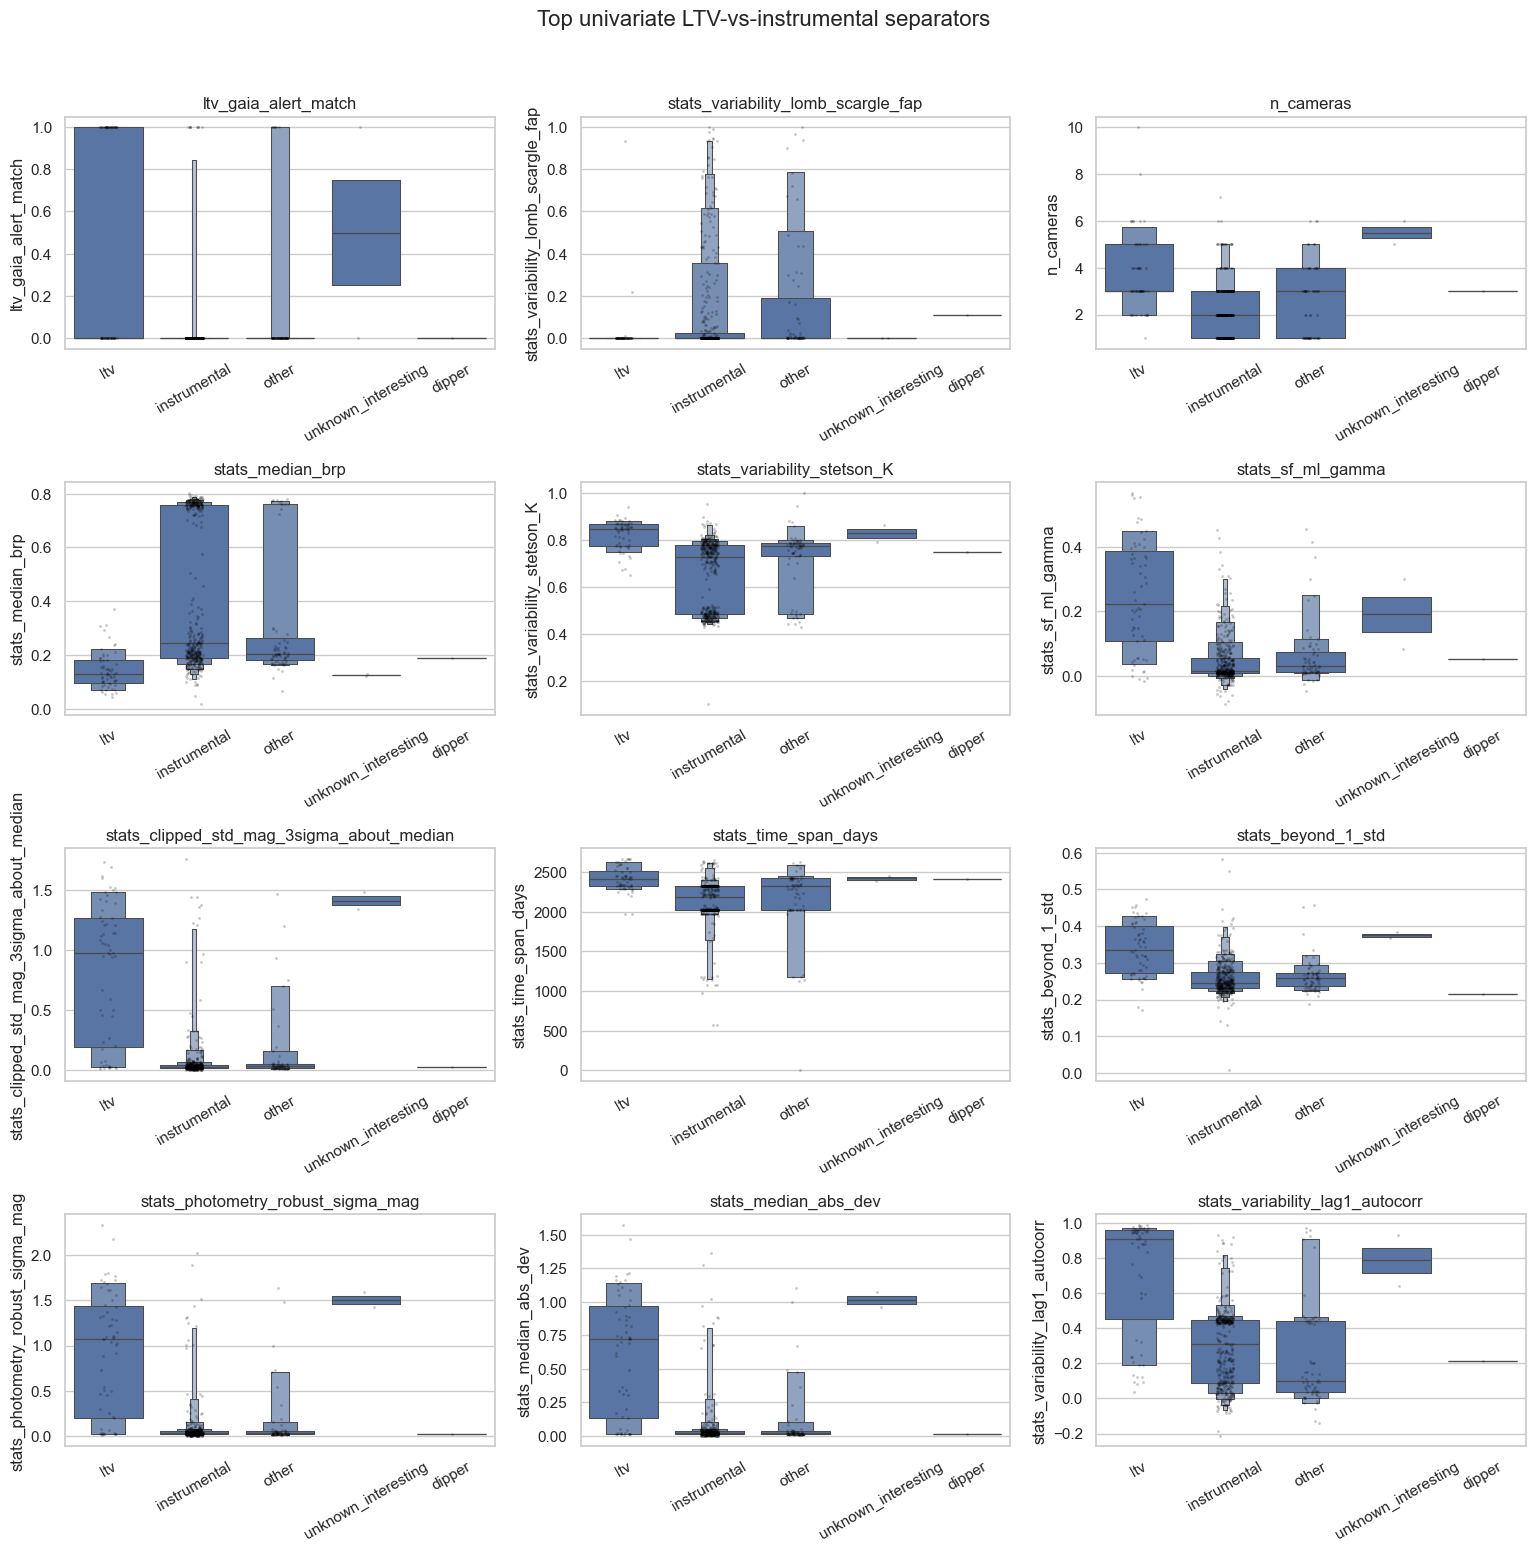

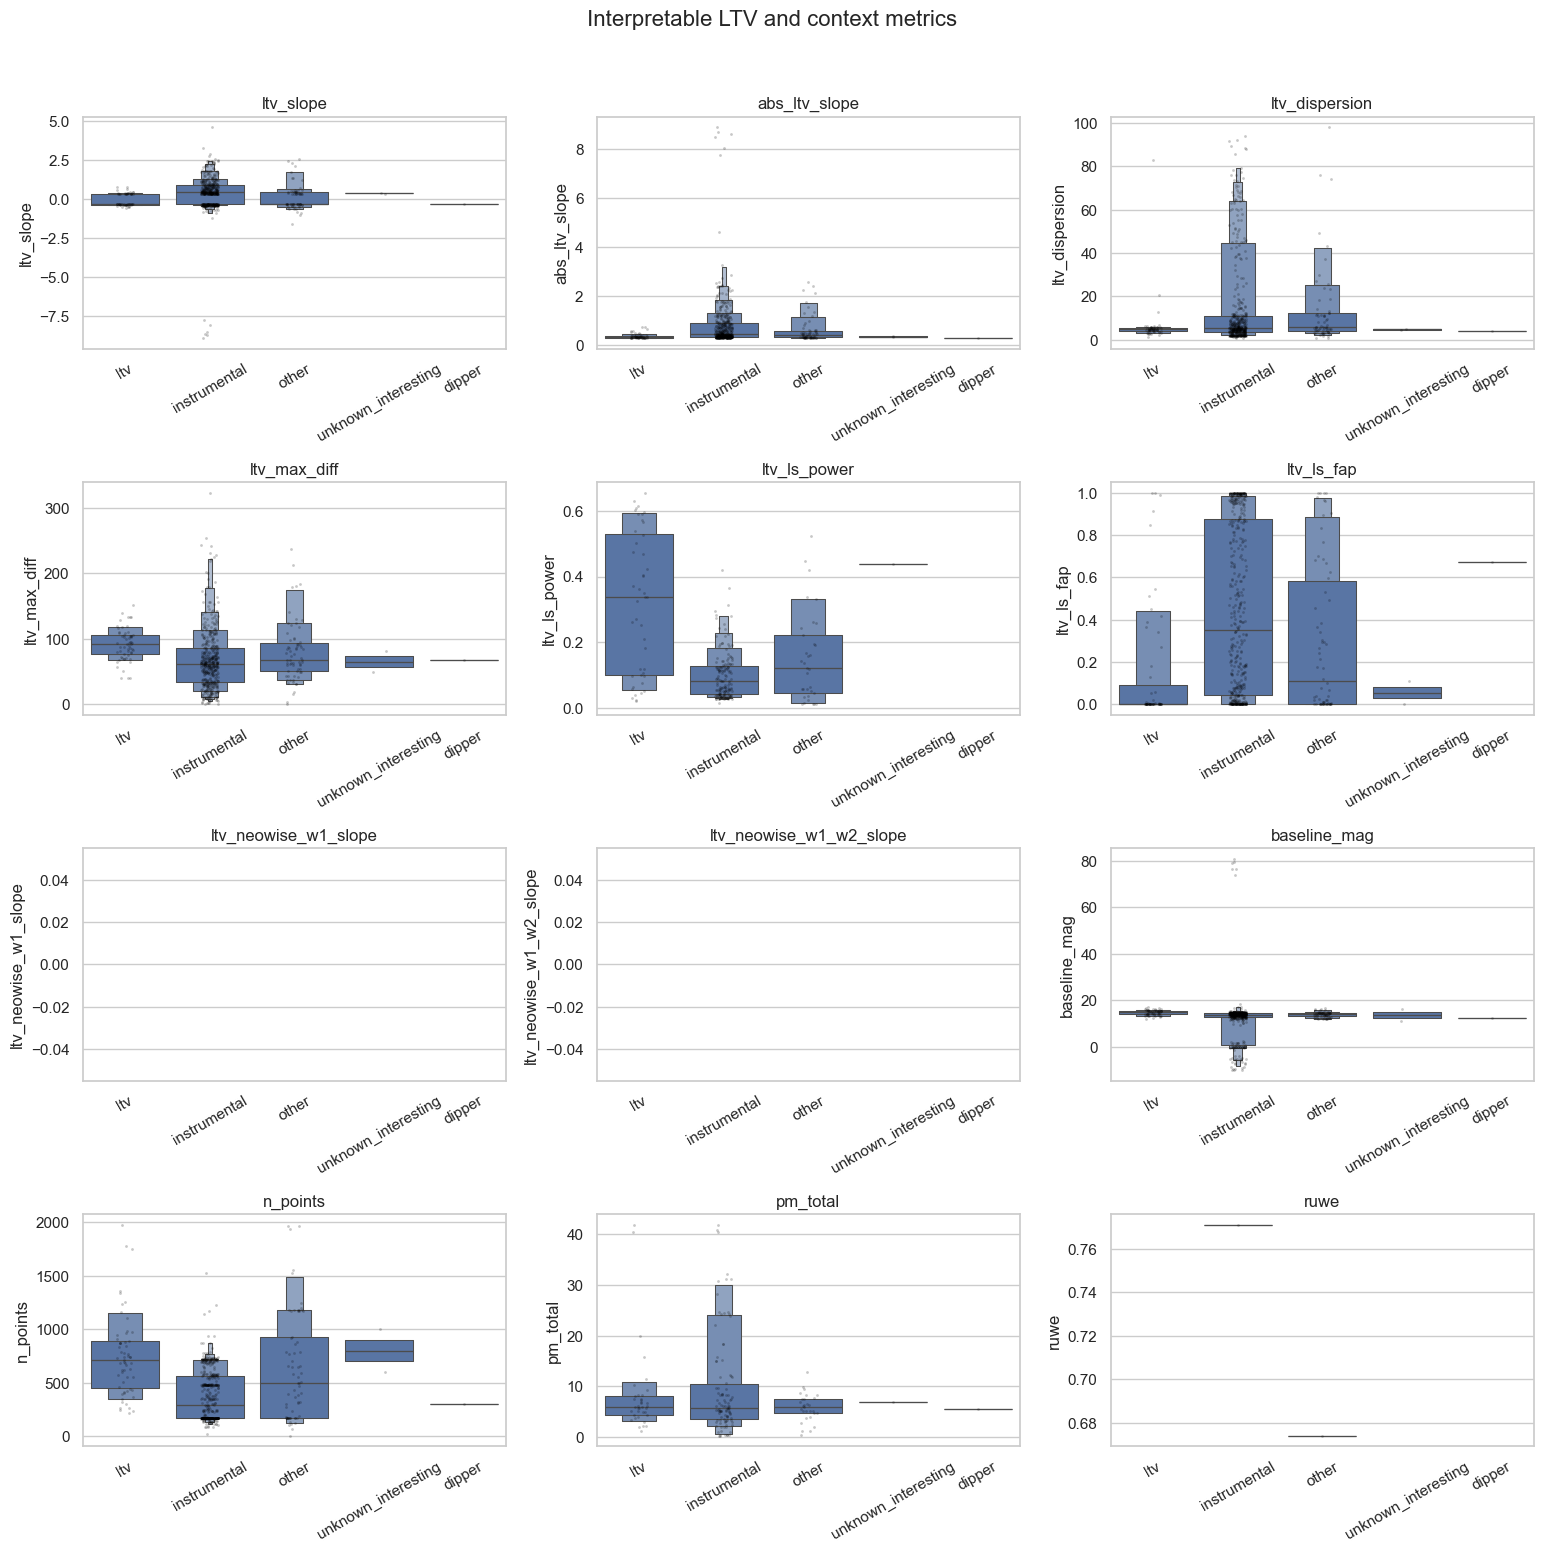

In [8]:
def plot_feature_grid(features: list[str], data: pd.DataFrame, *, max_features: int = 12, title: str = "") -> None:
    features = [f for f in features if f in data.columns]
    features = features[:max_features]
    if not features:
        print("No features to plot.")
        return
    ncols = 3
    nrows = math.ceil(len(features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), squeeze=False)
    plot_data = data.loc[data["event_class"].isin(CLASS_ORDER)].copy()
    plot_data["event_class"] = pd.Categorical(plot_data["event_class"], CLASS_ORDER, ordered=True)
    for ax, feature in zip(axes.ravel(), features):
        sns.boxenplot(data=plot_data, x="event_class", y=feature, order=CLASS_ORDER, ax=ax, showfliers=False)
        sns.stripplot(data=plot_data, x="event_class", y=feature, order=CLASS_ORDER, ax=ax, color="black", alpha=0.22, size=2)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)
        ax.set_title(feature)
    for ax in axes.ravel()[len(features):]:
        ax.axis("off")
    if title:
        fig.suptitle(title, y=1.02, fontsize=16)
    fig.tight_layout()
    plt.show()

top_univariate_features = test_results.head(12)["feature"].tolist()
plot_feature_grid(top_univariate_features, analysis, title="Top univariate LTV-vs-instrumental separators")

handpicked_for_plot = [
    "ltv_slope", "abs_ltv_slope", "ltv_dispersion", "ltv_max_diff", "ltv_ls_power", "ltv_ls_fap",
    "ltv_neowise_w1_slope", "ltv_neowise_w1_w2_slope", "baseline_mag", "n_points", "pm_total", "ruwe",
]
plot_feature_grid(handpicked_for_plot, analysis, title="Interpretable LTV and context metrics")


## Categorical And Flag Features

This section looks at low-cardinality flags and catalog matches. For binary flags it also computes Fisher's exact p-value for `ltv` vs `instrumental`; for general categories it reports Cramer's V.


In [9]:
def cramers_v(table: pd.DataFrame) -> float:
    table = table.loc[table.sum(axis=1) > 0, table.sum(axis=0) > 0]
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return float(np.sqrt((chi2 / n) / max(min(k - 1, r - 1), 1)))

categorical_rows = []
for col in low_card_cols:
    subset = binary_ltv_inst[["event_class", col]].dropna().copy()
    if subset.empty or subset[col].nunique(dropna=True) < 2:
        continue
    table = pd.crosstab(subset["event_class"], subset[col])
    fisher_p = np.nan
    if table.shape == (2, 2):
        try:
            fisher_p = stats.fisher_exact(table.to_numpy())[1]
        except Exception:
            fisher_p = np.nan
    categorical_rows.append({
        "feature": col,
        "n": int(table.to_numpy().sum()),
        "n_values": int(table.shape[1]),
        "cramers_v": cramers_v(table),
        "fisher_p_if_binary": fisher_p,
        "values": ", ".join(map(str, table.columns[:8])),
    })

cat_results = pd.DataFrame(categorical_rows)
if not cat_results.empty:
    cat_results["fisher_q_if_binary"] = bh_fdr(cat_results["fisher_p_if_binary"])
    cat_results = cat_results.sort_values(["fisher_q_if_binary", "cramers_v"], ascending=[True, False], na_position="last")
    display(cat_results.head(40))
else:
    print("No categorical features passed the screening criteria.")

IMPORTANT_CATS = [
    "ltv_passed_filters", "ltv_dust_candidate", "ltv_dust_excess", "ltv_vsx_match", "ltv_milliquas_match",
    "ltv_gaia_alert_match", "catalog_match", "catalog_source", "asassn_var_type", "gaia_var_class",
    "simbad_otype", "ztf_var_type", "microlens_match", "periodic_flag", "high_pm_flag",
]
IMPORTANT_CATS = [c for c in IMPORTANT_CATS if c in analysis.columns]

for col in IMPORTANT_CATS:
    display(Markdown(f"### {col}"))
    display(pd.crosstab(analysis["event_class"], analysis[col], margins=True, dropna=False))
    display(pd.crosstab(analysis["event_class"], analysis[col], normalize="index", dropna=False).round(3))


,feature,n,n_values,cramers_v,fisher_p_if_binary,values,fisher_q_if_binary
0,population,32,2,0.046374,1.0,"thin_disk_candidate, unknown",1.0
1,simbad_otype,48,13,0.767806,NaN,", *, C*, EB*, LP*, LP?, Mi*, OH*",NaN


### ltv_passed_filters

ltv_passed_filters,1,All
event_class,,
dipper,1,1
instrumental,459,459
ltv,59,59
other,67,67
unknown_interesting,2,2
All,588,588


ltv_passed_filters,1
event_class,
dipper,1.0
instrumental,1.0
ltv,1.0
other,1.0
unknown_interesting,1.0


### ltv_dust_candidate

...

periodic_flag,NaN,All
event_class,,
dipper,1,1
instrumental,459,459
ltv,59,59
other,67,67
unknown_interesting,2,2
All,0,588


periodic_flag,NaN
event_class,
dipper,1.0
instrumental,1.0
ltv,1.0
other,1.0
unknown_interesting,1.0


### high_pm_flag

high_pm_flag,0.0,NaN,All
event_class,,,
dipper,1,0,1
instrumental,102,357,459
ltv,37,22,59
other,29,38,67
unknown_interesting,1,1,2
All,170,0,588


high_pm_flag,0.0,NaN
event_class,,
dipper,1.000,0.000
instrumental,0.222,0.778
ltv,0.627,0.373
other,0.433,0.567
unknown_interesting,0.500,0.500


## Simple Predictive Check: Can A Baseline Model Separate LTV From Instrumental?

This is not intended as a production classifier. It is a sanity check: if cross-validated metrics are weak, there may not be an obvious statistical separator in the current feature set; if they are strong, inspect the coefficients and plots for candidate rules.


Rows: 518; positives/LTV: 59; negatives/instrumental: 459
Model numeric features: 154
Model categorical features: 0


,mean,std
roc_auc,0.939016,0.046544
average_precision,0.728541,0.134219
balanced_accuracy,0.846560,0.093620
f1,0.659169,0.102911


ROC AUC: 0.935
Average precision: 0.697
Balanced accuracy @ 0.5: 0.848
Confusion matrix @ 0.5 [rows=true, cols=pred]:


,pred_instrumental,pred_ltv
true_instrumental,428,31
true_ltv,14,45


              precision    recall  f1-score   support

instrumental       0.97      0.93      0.95       459
         ltv       0.59      0.76      0.67        59

    accuracy                           0.91       518
   macro avg       0.78      0.85      0.81       518
weighted avg       0.93      0.91      0.92       518



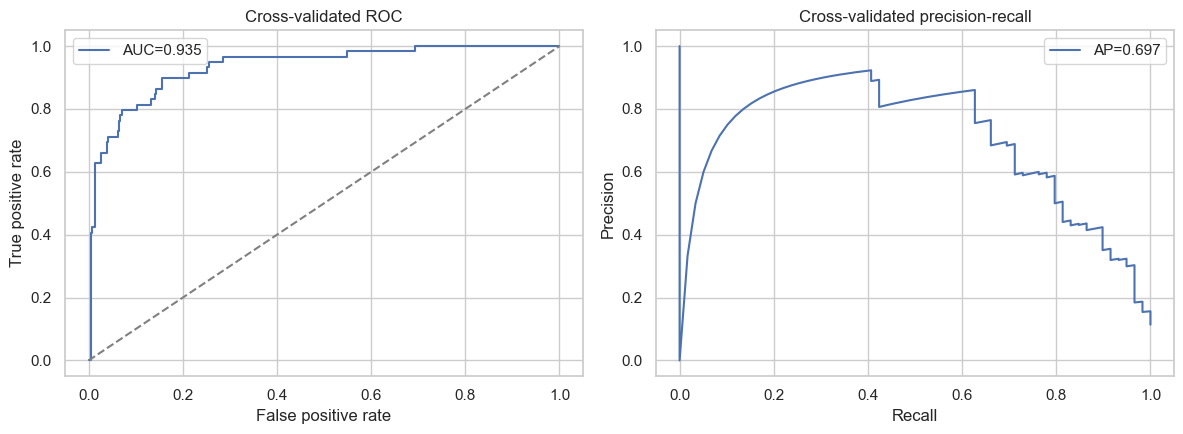

,candidate_id,asas_sn_id,event_class,interest_score,review_pass,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,baseline_mag,n_points,cv_ltv_probability
98,ltv_154619669336,154619669336,instrumental,4,2,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.339311,3.719394,86.838597,13.991612,245.0,1.000000
583,ltv_506807216854,506807216854,instrumental,4,2,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.400400,28.719160,2.296461,0.006230,476.0,1.000000
101,ltv_369368464201,369368464201,ltv,2,2,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.403796,5.668200,92.305905,15.785162,888.0,1.000000
176,ltv_644245639181,644245639181,ltv,1,3,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.369412,5.024122,118.176784,15.558379,621.0,1.000000
43,ltv_584116558061,584116558061,ltv,1,2,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.333979,5.957487,116.626566,15.635572,1162.0,1.000000
399,ltv_197568737545,197568737545,ltv,1,2,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.312399,4.351328,108.656444,15.692647,683.0,1.000000
273,ltv_120259220781,120259220781,ltv,1,2,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.316861,4.329800,103.565468,15.520463,779.0,1.000000
112,ltv_532576224135,532576224135,ltv,1,2,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.325771,5.880994,119.751264,15.918046,1352.0,0.999999
492,ltv_77309687301,77309687301,ltv,2,2,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.347137,3.644400,110.178157,16.285500,433.0,0.999992
364,ltv_558346598640,558346598640,ltv,1,2,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.335469,3.370500,102.585024,15.523757,317.0,0.999960


In [10]:
model_data = binary_ltv_inst.copy()
y = model_data["event_class"].eq("ltv").astype(int)

# Use all sufficiently populated numeric features plus selected low-cardinality context flags.
model_numeric = []
for col in numeric_cols:
    if col in EXCLUDE_FEATURES:
        continue
    nonmissing_frac = model_data[col].notna().mean()
    if nonmissing_frac >= 0.40 and model_data[col].nunique(dropna=True) > 1:
        model_numeric.append(col)

model_categorical = []
for col in low_card_cols:
    if col in EXCLUDE_FEATURES:
        continue
    nonmissing_frac = model_data[col].notna().mean()
    if nonmissing_frac >= 0.40 and 1 < model_data[col].nunique(dropna=True) <= 12:
        model_categorical.append(col)

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:  # older scikit-learn
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), model_numeric),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", onehot)]), model_categorical),
    ],
    remainder="drop",
)

logit = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear")),
])

print(f"Rows: {len(model_data):,}; positives/LTV: {int(y.sum()):,}; negatives/instrumental: {int((1-y).sum()):,}")
print(f"Model numeric features: {len(model_numeric)}")
print(f"Model categorical features: {len(model_categorical)}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["roc_auc", "average_precision", "balanced_accuracy", "f1"]
cv_scores = cross_validate(logit, model_data[model_numeric + model_categorical], y, cv=cv, scoring=scoring)
score_summary = pd.DataFrame({
    metric.replace("test_", ""): [cv_scores[metric].mean(), cv_scores[metric].std(ddof=1)]
    for metric in cv_scores
    if metric.startswith("test_")
}, index=["mean", "std"]).T

display(score_summary)

proba = cross_val_predict(logit, model_data[model_numeric + model_categorical], y, cv=cv, method="predict_proba")[:, 1]
pred = (proba >= 0.5).astype(int)
print("ROC AUC:", round(roc_auc_score(y, proba), 3))
print("Average precision:", round(average_precision_score(y, proba), 3))
print("Balanced accuracy @ 0.5:", round(balanced_accuracy_score(y, pred), 3))
print("Confusion matrix @ 0.5 [rows=true, cols=pred]:")
display(pd.DataFrame(confusion_matrix(y, pred), index=["true_instrumental", "true_ltv"], columns=["pred_instrumental", "pred_ltv"]))
print(classification_report(y, pred, target_names=["instrumental", "ltv"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fpr, tpr, _ = roc_curve(y, proba)
axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(y, proba):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()
axes[0].set_title("Cross-validated ROC")

precision, recall, _ = precision_recall_curve(y, proba)
axes[1].plot(recall, precision, label=f"AP={average_precision_score(y, proba):.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].set_title("Cross-validated precision-recall")
fig.tight_layout()
plt.show()

scored_binary = model_data[["candidate_id", "asas_sn_id", "event_class", "interest_score", "review_pass", "notes", "lc_path"] + [c for c in ["ltv_slope", "ltv_dispersion", "ltv_max_diff", "baseline_mag", "n_points"] if c in model_data.columns]].copy()
scored_binary["cv_ltv_probability"] = proba
display(scored_binary.sort_values("cv_ltv_probability", ascending=False).head(40))


## Model Coefficients

Positive coefficients push the baseline model toward `ltv`; negative coefficients push it toward `instrumental`. Correlated features can split or flip coefficients, so interpret these alongside the univariate plots.


,feature,coef_ltv_positive,abs_coef
39,num__stats_variability_von_neumann_ratio,1.617869,1.617869
126,num__ltv_vg_has_v,1.283782,1.283782
14,num__stats_cadence_p05_dt_days,-1.221755,1.221755
48,num__stats_variability_string_length_resid_total,-1.108788,1.108788
13,num__stats_cadence_median_dt_days,-0.991736,0.991736
4,num__cadence_median_days,-0.991736,0.991736
5,num__stats_file_points_total,0.991102,0.991102
70,num__stats_skew,-0.944162,0.944162
2,num__n_cameras,-0.903325,0.903325
64,num__stats_max_slope,0.771920,0.771920


/tmp/ipykernel_1869203/1639982263.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coef, y="feature", x="coef_ltv_positive", ax=ax, palette="vlag")


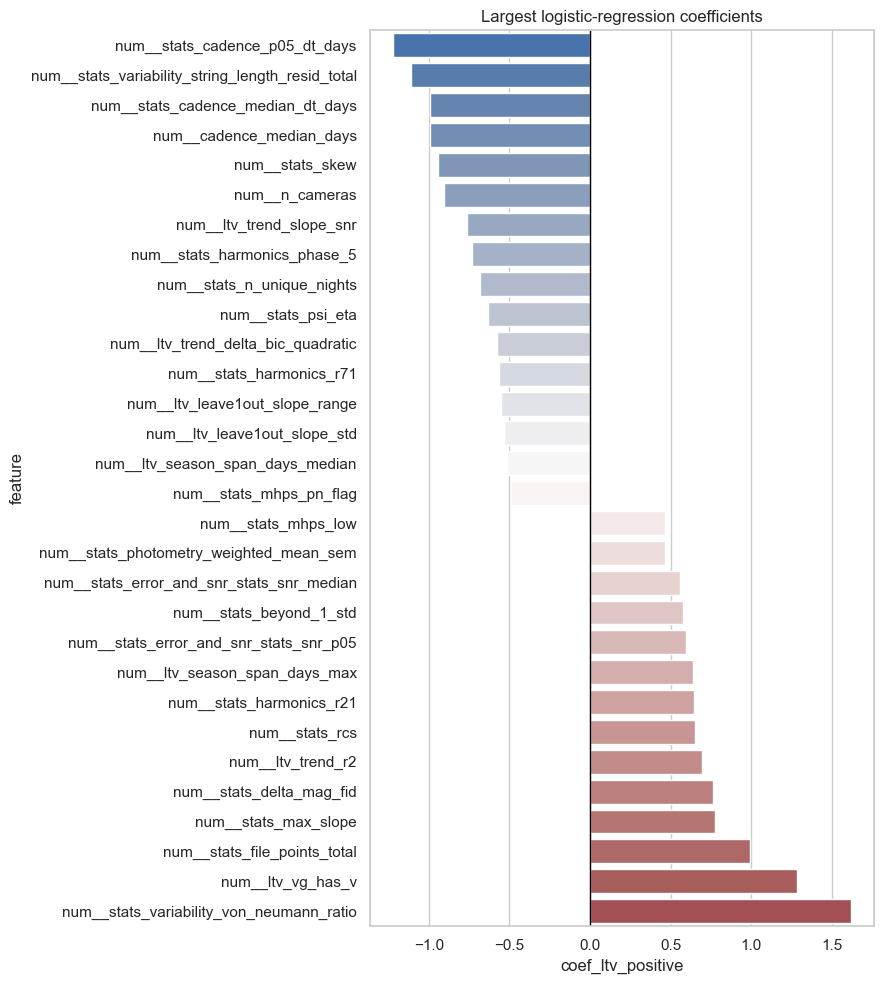

In [11]:
logit.fit(model_data[model_numeric + model_categorical], y)
try:
    feature_names = logit.named_steps["prep"].get_feature_names_out()
except Exception:
    feature_names = np.array(model_numeric + model_categorical, dtype=object)
coefs = logit.named_steps["clf"].coef_[0]
coef_table = pd.DataFrame({"feature": feature_names, "coef_ltv_positive": coefs})
coef_table["abs_coef"] = coef_table["coef_ltv_positive"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False)
display(coef_table.head(50))

fig, ax = plt.subplots(figsize=(9, 10))
top_coef = coef_table.head(30).sort_values("coef_ltv_positive")
sns.barplot(data=top_coef, y="feature", x="coef_ltv_positive", ax=ax, palette="vlag")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Largest logistic-regression coefficients")
fig.tight_layout()
plt.show()


## Low-Dimensional View Of Reviewed Candidates

PCA is only a visual diagnostic, but it helps show whether labels occupy obviously different parts of numeric-feature space.


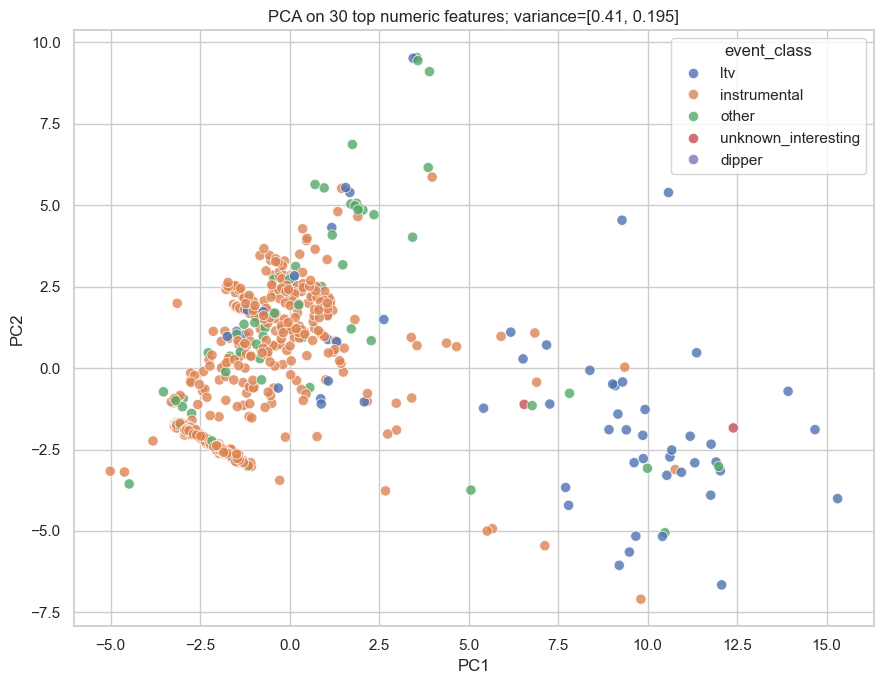

,candidate_id,event_class,PC1,PC2
8,ltv_17180383194,dipper,-1.479606,1.129265
451,ltv_120259761352,instrumental,-5.009632,-3.165008
108,ltv_120259761351,instrumental,-4.612685,-3.190673
105,ltv_223339099473,instrumental,-3.816238,-2.237328
170,ltv_292057880804,instrumental,-3.304354,-1.035907
42,ltv_51539977367,instrumental,-3.240773,-1.065235
449,ltv_137439476926,instrumental,-3.217652,-0.939008
23,ltv_17181193805,instrumental,-3.217107,-1.710433
21,ltv_17181148760,instrumental,-3.216897,-1.706063
57,ltv_1173853,instrumental,-3.215615,-1.775904


In [12]:
pca_features = test_results.head(30)["feature"].tolist()
pca_features = [f for f in pca_features if f in analysis.columns]
if len(pca_features) < 3:
    pca_features = INTERPRETABLE_FEATURES[:20]

pca_data = analysis.loc[analysis["event_class"].isin(CLASS_ORDER), ["candidate_id", "event_class"] + pca_features].copy()
X = pca_data[pca_features].apply(pd.to_numeric, errors="coerce")
X = SimpleImputer(strategy="median").fit_transform(X)
X = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
pca_plot = pca_data[["candidate_id", "event_class"]].copy()
pca_plot["PC1"] = coords[:, 0]
pca_plot["PC2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=pca_plot, x="PC1", y="PC2", hue="event_class", hue_order=CLASS_ORDER, alpha=0.8, s=55, ax=ax)
ax.set_title(f"PCA on {len(pca_features)} top numeric features; variance={pca.explained_variance_ratio_.round(3).tolist()}")
fig.tight_layout()
plt.show()

display(pca_plot.sort_values(["event_class", "PC1"]).head(30))


## Explore `other`, `unknown_interesting`, And `dipper`

These groups are too small or heterogeneous for strong inference, so this section focuses on candidate lists and nearest-neighbor context in the feature space used above.


In [13]:
NON_PRIMARY_LABELS = ["other", "unknown_interesting", "dipper"]
for label in NON_PRIMARY_LABELS:
    display(Markdown(f"### {label}"))
    display(candidate_table(label, max_rows=120))

# Compare each non-primary class against LTV and instrumental medians for the interpretable metrics.
profile_features = [c for c in INTERPRETABLE_FEATURES if analysis[c].notna().sum() >= 10]
profile = (
    analysis.loc[analysis["event_class"].isin(CLASS_ORDER)]
    .groupby("event_class")[profile_features]
    .median(numeric_only=True)
    .T
)
display(profile)

# Nearest neighbors for rare labels relative to reviewed LTV/instrumental candidates.
neighbor_features = pca_features[:20]
neighbor_base = analysis.loc[analysis["event_class"].isin(["ltv", "instrumental", "other", "unknown_interesting", "dipper"]), ["candidate_id", "event_class"] + neighbor_features].copy()
Xn = neighbor_base[neighbor_features].apply(pd.to_numeric, errors="coerce")
Xn = SimpleImputer(strategy="median").fit_transform(Xn)
Xn = StandardScaler().fit_transform(Xn)
neighbor_rows = []
for idx, row in neighbor_base.iterrows():
    if row["event_class"] not in NON_PRIMARY_LABELS:
        continue
    local_index = neighbor_base.index.get_loc(idx)
    d = np.sqrt(((Xn - Xn[local_index]) ** 2).sum(axis=1))
    order = np.argsort(d)
    for rank, j in enumerate(order[1:8], start=1):
        neighbor_rows.append({
            "candidate_id": row["candidate_id"],
            "event_class": row["event_class"],
            "neighbor_rank": rank,
            "neighbor_candidate_id": neighbor_base.iloc[j]["candidate_id"],
            "neighbor_event_class": neighbor_base.iloc[j]["event_class"],
            "distance": d[j],
        })
neighbors = pd.DataFrame(neighbor_rows)
display(neighbors)


### other

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
47,ltv_51539958368,51539958368,other,reviewed,4,2,2026-03-19 01:52:20.349919+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.336802,1.030618,33.690594,12.481700,NaN,6.242929e-01,None,None,1,0,0,0,1,12.501300,119.0,1.0,6.904001,NaN,None,None,None,None,None,None,None,EB*,EA,None
46,ltv_206159246990,206159246990,other,reviewed,4,2,2026-03-19 01:48:51.550472+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.345937,4.915728,81.346665,13.670900,NaN,2.855446e-01,None,None,1,0,0,0,0,13.685200,321.0,3.0,6.519397,NaN,None,None,None,None,None,None,None,None,None,None
13,ltv_85899492461,85899492461,other,reviewed,4,2,2026-03-19 01:22:51.051906+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.485362,3.901812,68.018575,12.287482,NaN,4.948385e-01,None,None,1,0,0,0,0,12.289083,394.0,4.0,8.757862,NaN,None,None,None,None,None,None,None,*,None,None
7,ltv_154619236699,154619236699,other,reviewed,4,2,2026-03-19 01:22:39.063202+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.351300,0.953800,32.247300,12.037300,NaN,6.998849e-01,None,None,1,0,0,0,0,12.047950,118.0,1.0,3.688668,NaN,None,None,None,None,None,None,None,*,None,None
99,ltv_51540578234,51540578234,other,reviewed,4,2,2026-03-19 01:22:28.537600+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.632667,5.483800,89.422282,13.260400,NaN,5.290693e-01,None,None,1,0,0,0,0,13.264300,136.0,1.0,12.759916,NaN,None,None,None,None,None,None,None,None,None,None
40,ltv_627066258907,627066258907,other,reviewed,4,2,2026-03-19 01:22:17.740548+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,2.140613,27.162600,184.120212,12.109426,NaN,3.424761e-01,None,None,1,0,0,0,0,12.111826,557.0,2.0,2.822461,0.673915,None,None,None,None,None,None,None,None,None,None
468,ltv_438087413518,438087413518,other,reviewed,4,2,2026-03-19 00:16:15.826641+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.341937,2.366800,108.481871,16.318950,0.118131,3.362288e-02,None,None,1,0,0,0,0,16.330300,175.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None
41,ltv_635655992254,635655992254,other,reviewed,4,2,2026-03-19 00:09:05.557224+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.616358,5.434500,85.349196,13.728612,NaN,8.958808e-01,None,None,1,0,0,0,0,14.023082,275.0,3.0,0.451128,NaN,None,None,None,None,None,None,None,None,None,None
15,ltv_644245411813,644245411813,other,reviewed,4,2,2026-03-19 00:06:53.275489+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.330155,5.071680,63.265373,12.089941,0.025879,8.571713e-11,None,None,1,0,1,0,0,12.083059,1552.0,5.0,7.528610,NaN,None,None,None,None,None,None,None,None,None,None
434,ltv_644246006094,644246006094,other,reviewed,4,2,2026-03-19 00:06:09.590974+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.462107,3.157300,59.671243,13.898700,NaN,9.998415e-01,None,None,1,0,0,0,0,13.974000,305.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


### unknown_interesting

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
260,ltv_618475941815,618475941815,unknown_interesting,reviewed,4,2,2026-03-19 04:48:37.761014+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.366041,4.963752,81.256214,16.127190,0.437744,3.375524e-121,None,None,1,0,0,0,1,16.12719,1003.0,6.0,6.856572,NaN,None,None,None,None,None,None,None,Mi*,None,None
80,ltv_489626718831,489626718831,unknown_interesting,reviewed,1,2,2026-03-19 01:33:53.544517+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.350557,4.700219,48.693471,10.781674,NaN,1.078671e-01,None,None,1,0,0,0,0,11.22375,596.0,5.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


### dipper

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
8,ltv_17180383194,17180383194,dipper,reviewed,1,2,2026-03-19 01:45:58.951049+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.311442,4.10887,66.89557,12.202554,NaN,0.674776,None,None,1,0,0,0,0,12.212355,296.0,3.0,5.629421,NaN,None,None,None,None,None,None,None,None,None,None


event_class,dipper,instrumental,ltv,other,unknown_interesting
ltv_slope,-0.311442,0.423699,-3.123988e-01,-0.300088,0.358299
abs_ltv_slope,0.311442,0.467140,3.471372e-01,0.406085,0.358299
ltv_slope_quad,-0.149012,-0.098303,-8.033060e-03,-0.104522,-0.071940
abs_ltv_slope_quad,0.149012,0.183747,7.949065e-02,0.158053,0.071940
ltv_dispersion,4.108870,5.492200,4.973500e+00,5.716272,4.831986
ltv_max_diff,66.895570,60.758657,9.230591e+01,68.018575,64.974843
ltv_median,12.202554,13.804850,1.478172e+01,14.040434,13.454432
ltv_median_err,0.072573,0.041751,1.005109e+00,0.045166,1.107354
ltv_ls_power,NaN,0.082139,3.373230e-01,0.124108,0.437744
ltv_ls_fap,0.674776,0.350619,3.390450e-10,0.106973,0.053934


,candidate_id,event_class,neighbor_rank,neighbor_candidate_id,neighbor_event_class,distance
0,ltv_1077152,other,1,ltv_618475649006,instrumental,1.027013
1,ltv_1077152,other,2,ltv_85899418023,instrumental,1.519122
2,ltv_1077152,other,3,ltv_472446917262,instrumental,1.587430
3,ltv_1077152,other,4,ltv_1082427,other,1.802563
4,ltv_1077152,other,5,ltv_541166256373,instrumental,2.106396
...,...,...,...,...,...,...
485,ltv_103080258537,other,3,ltv_223339099473,instrumental,5.241944
486,ltv_103080258537,other,4,ltv_429497602690,instrumental,7.989125
487,ltv_103080258537,other,5,ltv_85900572301,instrumental,8.017378
488,ltv_103080258537,other,6,ltv_94490036985,instrumental,8.113466


## Light-Curve Inspection Helpers

Use `plot_candidate_lightcurve("ltv_...")` or `plot_class_examples("ltv", n=4)` to inspect the source `.dat2` files. The y-axis is inverted because these are magnitudes.


In [14]:
def resolve_lc_path(value: object) -> Path | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    raw = str(value)
    if not raw:
        return None
    path = Path(raw).expanduser()
    candidates = [path]
    if not path.is_absolute():
        candidates.extend([
            REPO_ROOT / path,
            DB_PATH.parent / path,
            DB_PATH.parent / "bundle_assets" / "lightcurves" / path.name,
        ])
    else:
        # If the absolute path came from another checkout, fall back by file name.
        candidates.append(REPO_ROOT / "output" / "ltv" / "ltv" / "bundle_assets" / "lightcurves" / path.name)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return path

def read_dat2(path: Path) -> pd.DataFrame:
    cols = ["time", "mag", "mag_err", "quality_flag", "camera", "field_flag", "unknown_flag", "image"]
    df = pd.read_csv(path, sep=r"\s+", header=None, names=cols, comment="#", engine="python")
    for col in ["time", "mag", "mag_err", "quality_flag", "camera", "field_flag", "unknown_flag"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.dropna(subset=["time", "mag"])

def plot_candidate_lightcurve(candidate_id: str, *, color_by_camera: bool = True, max_legend: int = 12) -> pd.DataFrame:
    rows = analysis.loc[analysis["candidate_id"].eq(candidate_id)]
    if rows.empty:
        raise KeyError(f"candidate_id not found: {candidate_id}")
    row = rows.iloc[0]
    path = resolve_lc_path(row.get("lc_path"))
    if path is None or not path.exists():
        raise FileNotFoundError(f"No light curve file found for {candidate_id}: {row.get('lc_path')}")
    lc = read_dat2(path)
    fig, ax = plt.subplots(figsize=(11, 4.8))
    if color_by_camera and "camera" in lc.columns:
        for camera, g in lc.groupby("camera", dropna=False):
            label = f"cam {int(camera)}" if pd.notna(camera) else "cam NA"
            ax.errorbar(g["time"], g["mag"], yerr=g["mag_err"], fmt=".", ms=3, alpha=0.65, label=label)
        if lc["camera"].nunique(dropna=True) <= max_legend:
            ax.legend(ncol=2, fontsize=8)
    else:
        ax.errorbar(lc["time"], lc["mag"], yerr=lc["mag_err"], fmt=".", ms=3, alpha=0.65)
    ax.invert_yaxis()
    ax.set_xlabel("time")
    ax.set_ylabel("mag")
    ax.set_title(
        f"{candidate_id} | class={row.get('event_class')} | score={row.get('interest_score')} | "
        f"ltv_slope={row.get('ltv_slope')} | dispersion={row.get('ltv_dispersion')}"
    )
    fig.tight_layout()
    plt.show()
    display(row[KEY_DISPLAY_COLS].to_frame().T)
    return lc

def plot_class_examples(label: str, n: int = 4, *, sort_by: str = "interest_score") -> list[pd.DataFrame]:
    data = analysis.loc[analysis["event_class"].eq(label)].copy()
    if data.empty:
        print(f"No rows for {label}")
        return []
    ascending = False if sort_by in {"interest_score", "updated_at", "ltv_dispersion", "ltv_max_diff"} else True
    data = data.sort_values([sort_by, "candidate_id"], ascending=[ascending, True]).head(n)
    out = []
    for cid in data["candidate_id"]:
        try:
            out.append(plot_candidate_lightcurve(cid))
        except Exception as exc:
            print(f"{cid}: {exc}")
    return out


## Example Light Curves

These examples are chosen from each reviewed class. Change the `n` values or call `plot_candidate_lightcurve()` with any candidate ID from the tables above.


### ltv examples

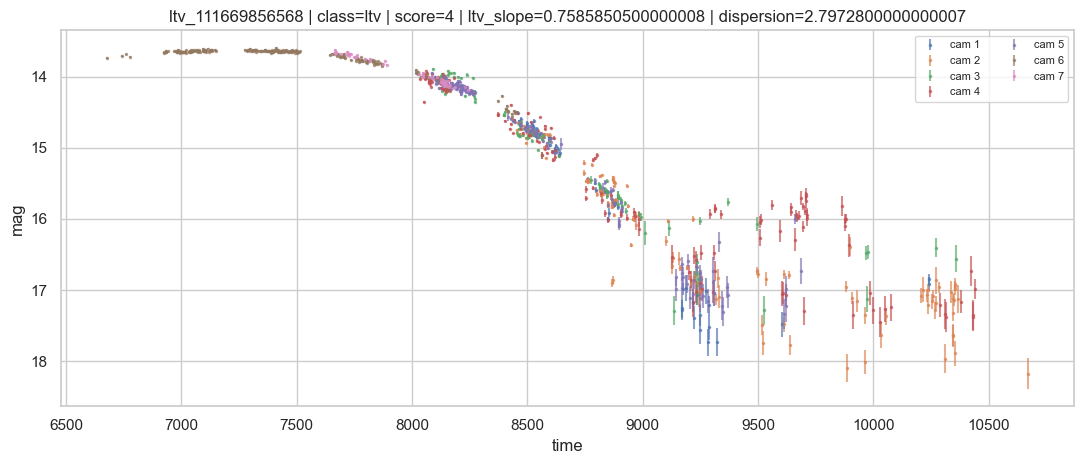

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
259,ltv_111669856568,111669856568,ltv,reviewed,4,1,2026-03-19 05:55:58.496730+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.758585,2.79728,40.317527,14.7093,0.076797,0.000878,None,None,1,0,0,0,0,15.105467,597.0,5.0,5.745444,NaN,None,None,None,None,None,None,None,None,None,None


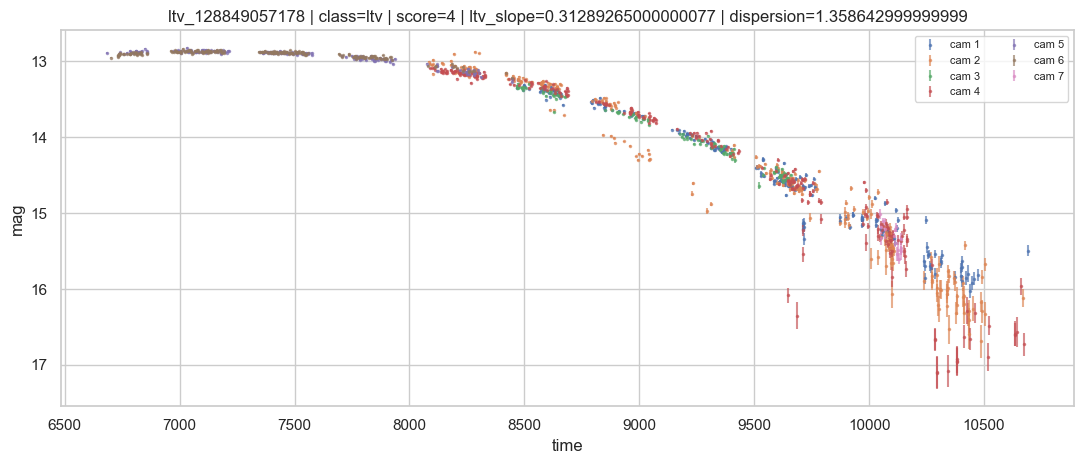

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
55,ltv_128849057178,128849057178,ltv,reviewed,4,2,2026-03-19 01:06:17.315252+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.312893,1.358643,39.769925,13.441043,NaN,0.916359,None,None,1,0,0,0,0,14.1337,881.0,5.0,7.52861,NaN,None,None,None,None,None,None,None,None,None,None


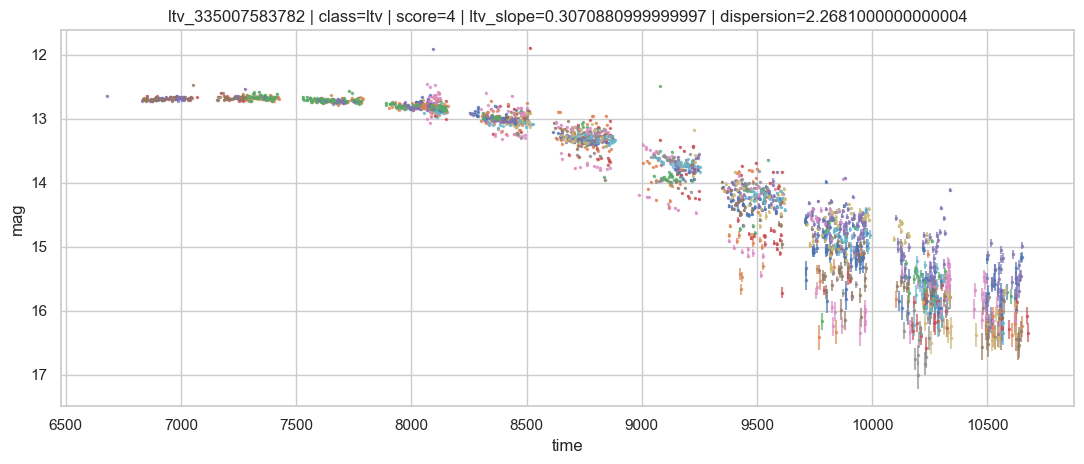

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
274,ltv_335007583782,335007583782,ltv,reviewed,4,2,2026-03-19 00:25:17.022359+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.307088,2.2681,50.84234,13.133356,NaN,0.447929,None,None,1,0,0,0,0,13.963634,1777.0,10.0,5.099226,NaN,None,None,None,None,None,None,None,*,None,None


### instrumental examples

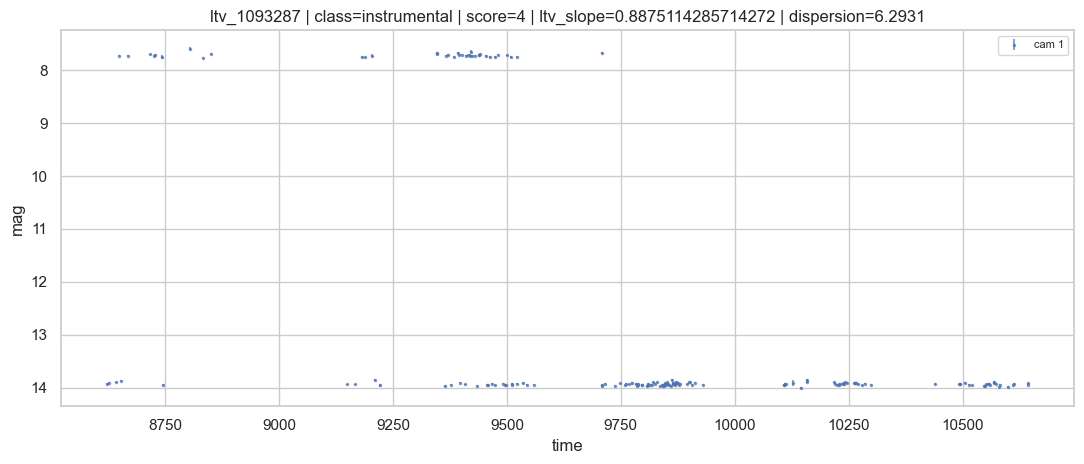

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
206,ltv_1093287,1093287,instrumental,reviewed,4,2,2026-03-19 01:26:36.343483+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.887511,6.2931,10.154697,13.935,NaN,0.682471,None,None,1,0,0,0,0,13.9276,167.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


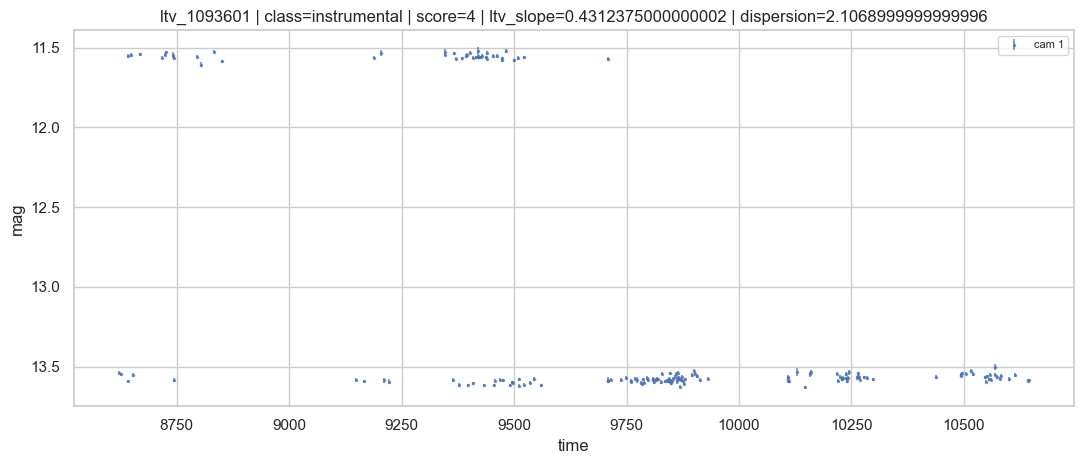

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
187,ltv_1093601,1093601,instrumental,reviewed,4,2,2026-03-19 04:23:28.640008+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.431238,2.1069,60.1387,13.5772,NaN,0.990388,None,None,1,0,0,0,0,13.57155,170.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


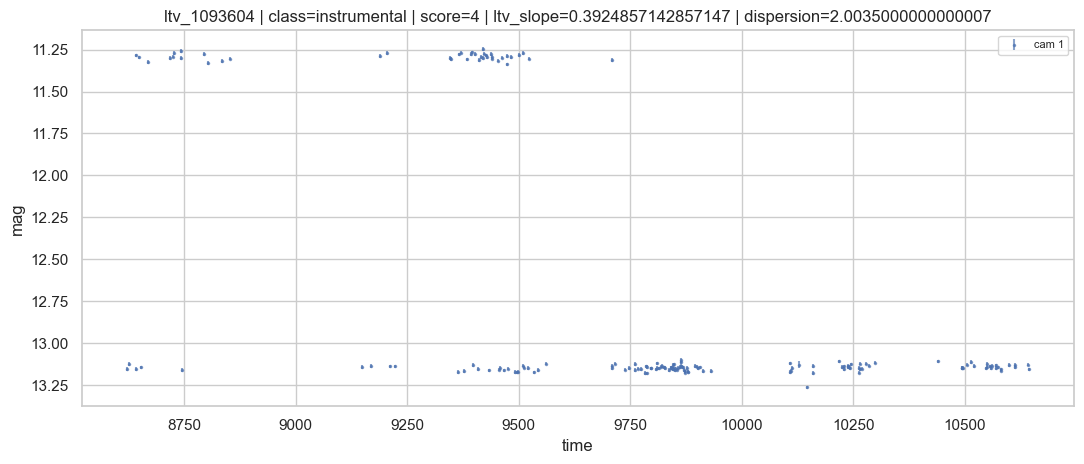

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
132,ltv_1093604,1093604,instrumental,reviewed,4,2,2026-03-19 04:22:07.153733+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.392486,2.0035,59.381814,13.14015,NaN,0.982914,None,None,1,0,0,0,0,13.1381,169.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


### other examples

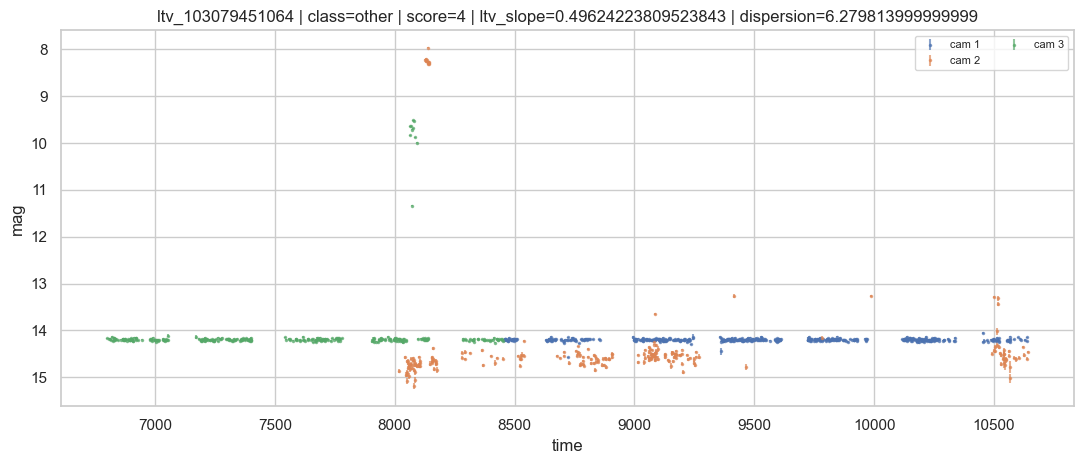

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
269,ltv_103079451064,103079451064,other,reviewed,4,2,2026-03-19 00:01:58.863776+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.496242,6.279814,36.980478,14.1974,0.106312,0.000014,None,None,1,0,0,0,0,14.1971,495.0,1.0,7.501807,NaN,None,None,None,None,None,None,None,None,None,None


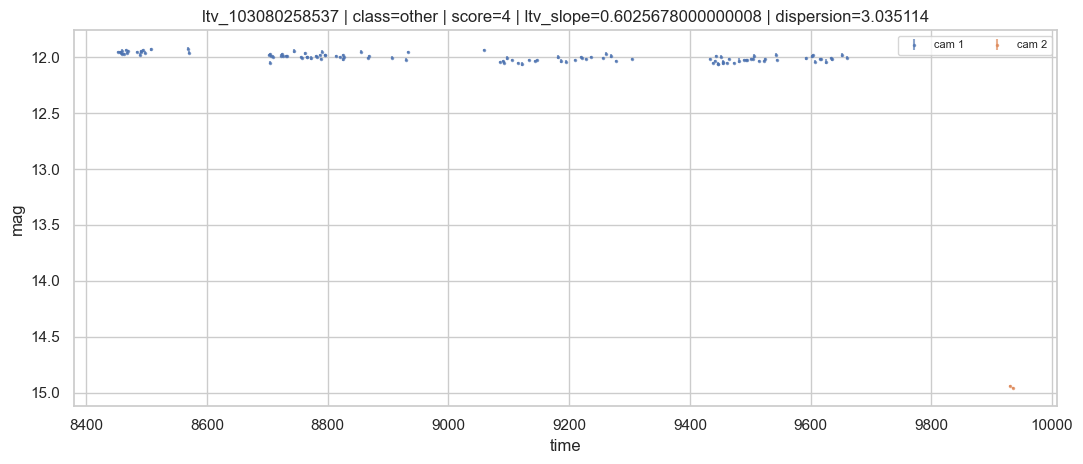

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
584,ltv_103080258537,103080258537,other,reviewed,4,2,2026-03-19 00:02:20.263230+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.602568,3.035114,64.456991,11.999636,0.245192,0.006583,None,None,1,0,0,0,0,14.95025,2.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


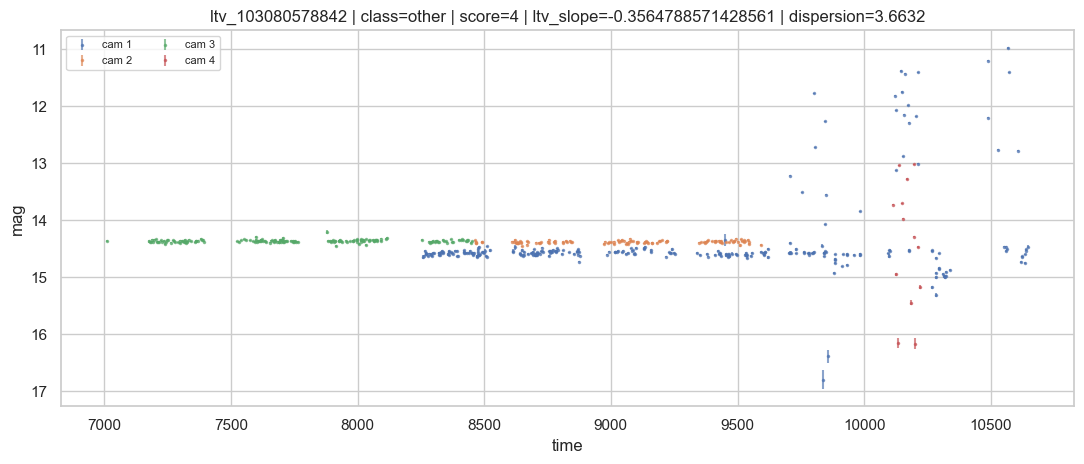

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
418,ltv_103080578842,103080578842,other,reviewed,4,2,2026-03-19 00:02:29.577229+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.356479,3.6632,79.023308,14.400755,NaN,0.599102,None,None,1,0,0,0,0,14.380205,108.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


### unknown_interesting examples

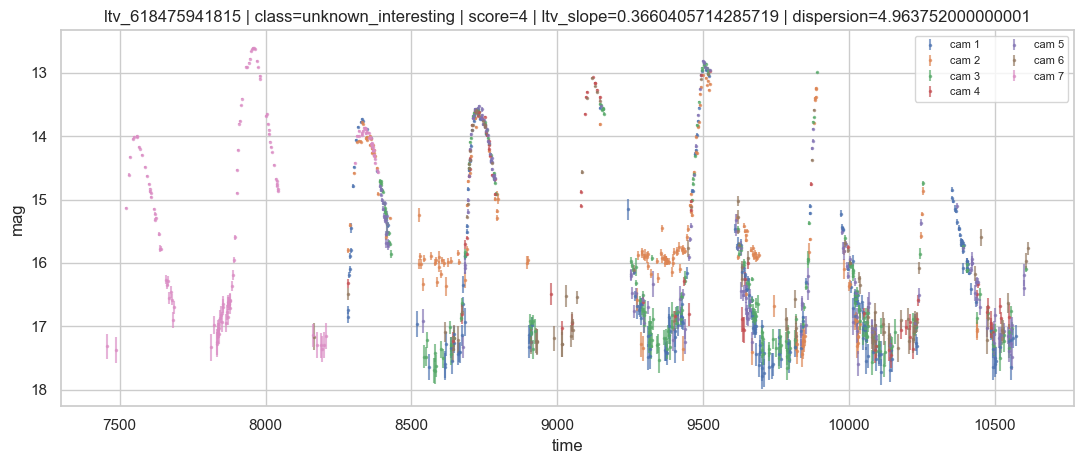

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
260,ltv_618475941815,618475941815,unknown_interesting,reviewed,4,2,2026-03-19 04:48:37.761014+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.366041,4.963752,81.256214,16.12719,0.437744,0.0,None,None,1,0,0,0,1,16.12719,1003.0,6.0,6.856572,NaN,None,None,None,None,None,None,None,Mi*,None,None


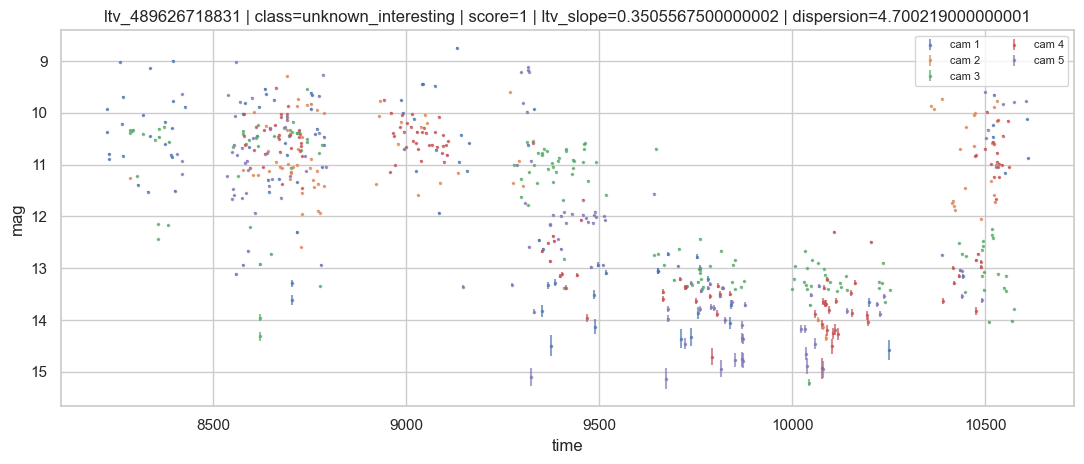

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
80,ltv_489626718831,489626718831,unknown_interesting,reviewed,1,2,2026-03-19 01:33:53.544517+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.350557,4.700219,48.693471,10.781674,NaN,0.107867,None,None,1,0,0,0,0,11.22375,596.0,5.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


### dipper examples

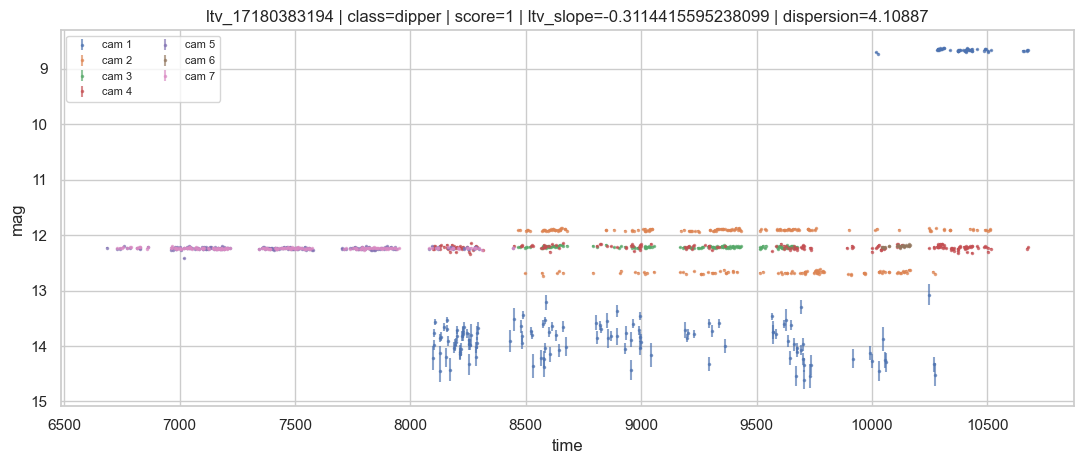

,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
8,ltv_17180383194,17180383194,dipper,reviewed,1,2,2026-03-19 01:45:58.951049+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.311442,4.10887,66.89557,12.202554,NaN,0.674776,None,None,1,0,0,0,0,12.212355,296.0,3.0,5.629421,NaN,None,None,None,None,None,None,None,None,None,None


In [15]:
for label, n in [("ltv", 3), ("instrumental", 3), ("other", 3), ("unknown_interesting", 2), ("dipper", 1)]:
    display(Markdown(f"### {label} examples"))
    _ = plot_class_examples(label, n=n, sort_by="interest_score")


## Candidate Rule Sandbox

Use this cell to test candidate cuts suggested by the plots and statistics. The example is intentionally conservative and should be edited after inspecting the results above.


In [16]:
def evaluate_rule(mask: pd.Series, data: pd.DataFrame = binary_ltv_inst) -> pd.DataFrame:
    selected = data.loc[mask.reindex(data.index, fill_value=False)].copy()
    rows = []
    for label in ["ltv", "instrumental"]:
        label_total = int(data["event_class"].eq(label).sum())
        label_selected = int(selected["event_class"].eq(label).sum())
        rows.append({
            "event_class": label,
            "selected": label_selected,
            "total": label_total,
            "recall_within_class": label_selected / label_total if label_total else np.nan,
            "composition_of_selected": label_selected / len(selected) if len(selected) else np.nan,
        })
    return pd.DataFrame(rows)

# Edit this based on the features that look useful in test_results / plots.
rule = pd.Series(True, index=analysis.index)
for col, op, value in [
    ("ltv_passed_filters", "==", 1),
    # ("ltv_dispersion", ">", 2.0),
    # ("abs_ltv_slope", ">", 0.25),
]:
    if col not in analysis.columns:
        continue
    if op == "==":
        rule &= analysis[col].eq(value)
    elif op == ">":
        rule &= pd.to_numeric(analysis[col], errors="coerce").gt(value)
    elif op == "<":
        rule &= pd.to_numeric(analysis[col], errors="coerce").lt(value)

display(evaluate_rule(rule))
display(analysis.loc[rule & analysis["event_class"].isin(["ltv", "instrumental"]), KEY_DISPLAY_COLS].head(80))


,event_class,selected,total,recall_within_class,composition_of_selected
0,ltv,59,59,1.0,0.1139
1,instrumental,459,459,1.0,0.8861


,candidate_id,asas_sn_id,event_class,review_status,interest_score,review_pass,updated_at,notes,lc_path,ltv_slope,ltv_dispersion,ltv_max_diff,ltv_median,ltv_ls_power,ltv_ls_fap,ltv_neowise_w1_slope,ltv_neowise_w1_w2_slope,ltv_passed_filters,ltv_dust_candidate,ltv_vsx_match,ltv_milliquas_match,ltv_gaia_alert_match,baseline_mag,n_points,n_cameras,pm_total,ruwe,periodicity_score,dipper_score,jumper_score,catalog_match,catalog_source,asassn_var_type,gaia_var_class,simbad_otype,ztf_var_type,microlens_match
0,ltv_240518590836,240518590836,instrumental,reviewed,4,2,2026-03-19 01:48:05.962458+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.339237,6.493608,74.053028,12.848131,0.052557,7.798272e-02,None,None,1,0,0,0,0,12.863975,306.0,3.0,8.301576,NaN,None,None,None,None,None,None,None,*,None,None
1,ltv_618475649006,618475649006,instrumental,reviewed,4,2,2026-03-19 01:39:22.560425+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.345793,6.668304,39.216850,11.601082,NaN,4.685709e-01,None,None,1,0,0,0,0,11.614782,253.0,1.0,4.461074,NaN,None,None,None,None,None,None,None,None,None,None
3,ltv_154619046438,154619046438,instrumental,reviewed,4,2,2026-03-19 01:23:41.707534+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.310542,0.847443,33.305206,12.232300,NaN,6.502015e-01,None,None,1,0,0,0,0,12.247600,117.0,1.0,5.671983,NaN,None,None,None,None,None,None,None,None,None,None
4,ltv_223338556492,223338556492,instrumental,reviewed,4,2,2026-03-19 01:24:37.502198+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.318311,4.520574,64.693163,12.085227,NaN,3.863612e-01,None,None,1,0,0,0,0,12.086742,753.0,6.0,5.013152,NaN,None,None,None,None,None,None,None,*,None,None
5,ltv_8591260810,8591260810,ltv,reviewed,1,2,2026-03-19 01:35:07.060505+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.314161,4.724543,68.679744,12.062939,0.041192,1.099935e-02,None,None,1,0,0,0,0,12.073639,302.0,3.0,6.904001,NaN,None,None,None,None,None,None,None,*,None,None
9,ltv_223339103684,223339103684,instrumental,reviewed,4,2,2026-03-19 04:07:15.095197+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.307270,9.346609,75.444440,12.327438,0.058801,1.042296e-07,None,None,1,0,0,0,0,12.309088,427.0,3.0,8.342792,NaN,None,None,None,None,None,None,None,*,None,None
10,ltv_309237686439,309237686439,instrumental,reviewed,4,2,2026-03-19 01:23:18.664865+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.303638,1.561760,32.475952,12.147927,NaN,7.782013e-01,None,None,1,0,0,0,0,12.150209,367.0,4.0,3.891814,NaN,None,None,None,None,None,None,None,PM*,None,None
12,ltv_1300571,1300571,instrumental,reviewed,4,2,2026-03-19 01:20:58.668412+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,0.441555,5.423084,30.016579,12.231164,NaN,2.646962e-01,None,None,1,0,0,0,0,12.231264,227.0,1.0,12.315669,NaN,None,None,None,None,None,None,None,None,None,None
14,ltv_463857471470,463857471470,instrumental,reviewed,4,2,2026-03-19 01:23:29.914995+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,-0.359119,4.260683,72.697374,12.293119,0.052925,1.900243e-02,None,None,1,0,0,0,0,12.294900,299.0,2.0,5.182356,NaN,None,None,None,None,None,None,None,*,None,None
16,ltv_17181187243,17181187243,instrumental,reviewed,4,2,2026-03-19 00:44:52.206018+00:00,,/home/calder/code/malca/output/ltv/ltv/bundle_...,2.143293,10.137100,31.445743,12.346000,NaN,9.787548e-01,None,None,1,0,0,0,0,12.346000,167.0,1.0,NaN,NaN,None,None,None,None,None,None,None,None,None,None


## Export Optional Tables

Uncomment this cell if you want CSV snapshots of the most useful tables next to the notebook.


In [ ]:
# out_dir = REPO_ROOT / "output" / "ltv" / "analysis_tables"
# out_dir.mkdir(parents=True, exist_ok=True)
# candidate_table(None, max_rows=len(reviewed)).to_csv(out_dir / "reviewed_ltv_candidate_table.csv", index=False)
# test_results.to_csv(out_dir / "ltv_vs_instrumental_numeric_tests.csv", index=False)
# coef_table.to_csv(out_dir / "ltv_vs_instrumental_logit_coefficients.csv", index=False)
# print(f"Wrote tables to {out_dir}")
